# Linear memory from phenomelogical models

As proposed by Lopez et al. (https://arxiv.org/html/2305.04761v3) or by Favata (https://www.phy.olemiss.edu/StronGBaD/talks/Favata.pdf), the time evolution of the linear memory from the ejecta can be `phenomenologically` modeled using either an exponential or a hyperbolic tangent function. In this notebook, we compare these models and introduce the contribution of the 2 ejecta components (dynamical and wind).

## General function to plot the models

In [1]:
import utils_phenom as up
import utils_signal as using
import importlib

importlib.reload(up)
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, PC_SI, C_SI, G_SI
out_dir = "./figures/"


/home/pycbc/work/Memory_Lopez/utils_phenom.py:4: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI, PC_SI, C_SI, G_SI


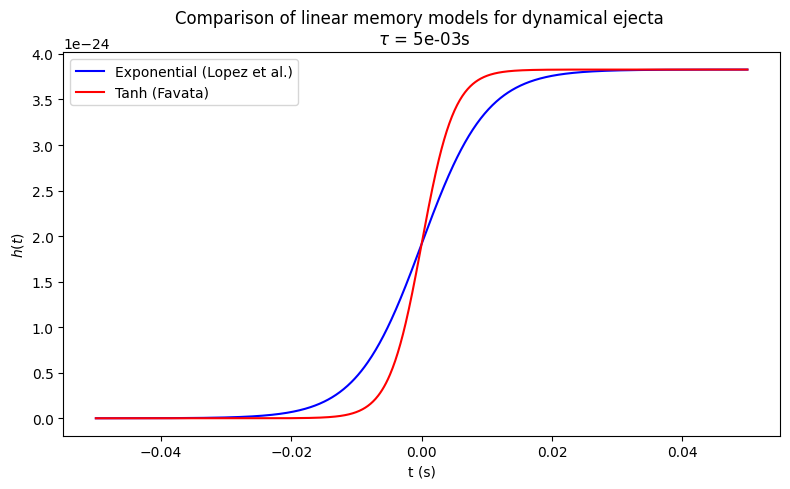

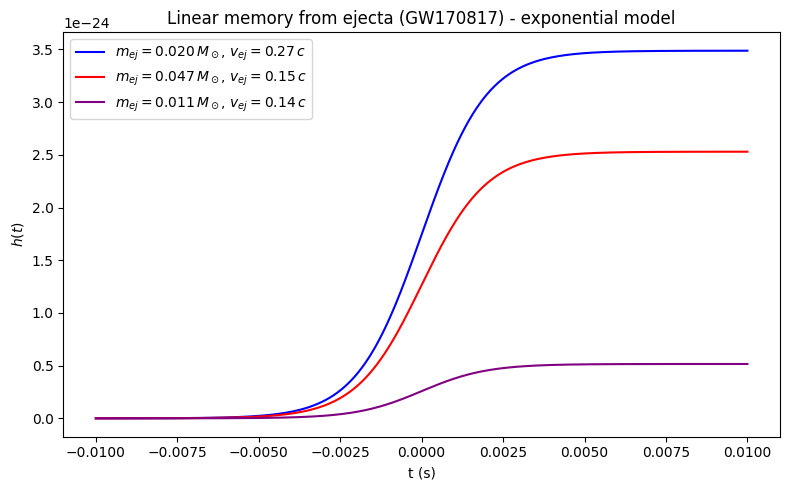

In [14]:
# 1. Plot for typical dynamical ejecta (Lopez vs Favata)
tau = 5e-3  # s
M_ej_dyn = 0.04  # solar masses
v_ej_dyn = 0.2   # m/s
r = 40e6  # Mparsecs
t = np.linspace(-0.05, 0.05, 1000)

# Exponential model
_, h_lopez = up.phenom_memory_models(tau, M_ej_dyn, v_ej_dyn, r, t, model='exponential', plot=0)
# Tanh model
_, h_favata = up.phenom_memory_models(tau, M_ej_dyn, v_ej_dyn, r, t, model='tanh', plot=0)

plt.figure(figsize=(8, 5))
plt.plot(t, h_lopez, label='Exponential (Lopez et al.)', color='blue')
plt.plot(t, h_favata, label='Tanh (Favata)', color='red')
plt.xlabel("t (s)")
plt.ylabel(r"$h(t)$")
plt.title(f"Comparison of linear memory models for dynamical ejecta \n $\\tau$ = {tau:.0e}s")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir + f"memory_comparison_dynamical_ejecta_tau_{tau:.0e}s.png")
plt.show()

# 2. Plot for GW170817 ejecta components (Lopez model)
M_ej_arr = np.array([0.02, 0.047, 0.011])  # solar masses
v_ej_arr = np.array([0.27, 0.15, 0.14])   # m/s
r_gw = 40e6  # parsecs
tau_gw = 0.001  # s
t_gw = np.linspace(-0.01, 0.01, 1000)
colors = ['blue', 'red', 'purple']

plt.figure(figsize=(8, 5))
for i in range(3):
    _, h = up.phenom_memory_models(tau_gw, M_ej_arr[i], v_ej_arr[i], r_gw, t_gw, model='exponential', plot=False)
    plt.plot(t_gw, h, color=colors[i],
             label=f"$m_{{ej}}={M_ej_arr[i]:.3f}\\,M_\\odot$, $v_{{ej}}={v_ej_arr[i]:.2f}\\,c$")
plt.xlabel("t (s)")
plt.ylabel(r"$h(t)$")
plt.title("Linear memory from ejecta (GW170817) - exponential model")
plt.legend()
plt.tight_layout()
plt.savefig(out_dir + "memory_gw170817_ejecta_test_models.png")
plt.show()

## Plot of the dynamical, wind and total memory for a given model

To be more physcially motivated, we can apply masks to the memory evolution, so that the memory grows only during the time of activity of each ejecta component. After the end of the activity, the memory remains constant. This is done in the function `linear_memory_ejecta_masked` defined in `utils_phenom.py`. Based on the Table 1 of https://arxiv.org/pdf/1912.05659, the typical time of activity of each ejecta component is given by the following ranges:
- Dynamical ejecta: 0 to 10 ms with a caracteristic timescale of 1 ms
- Wind ejecta: 10 ms to 10 s with a caracteristic timescale of 1 s

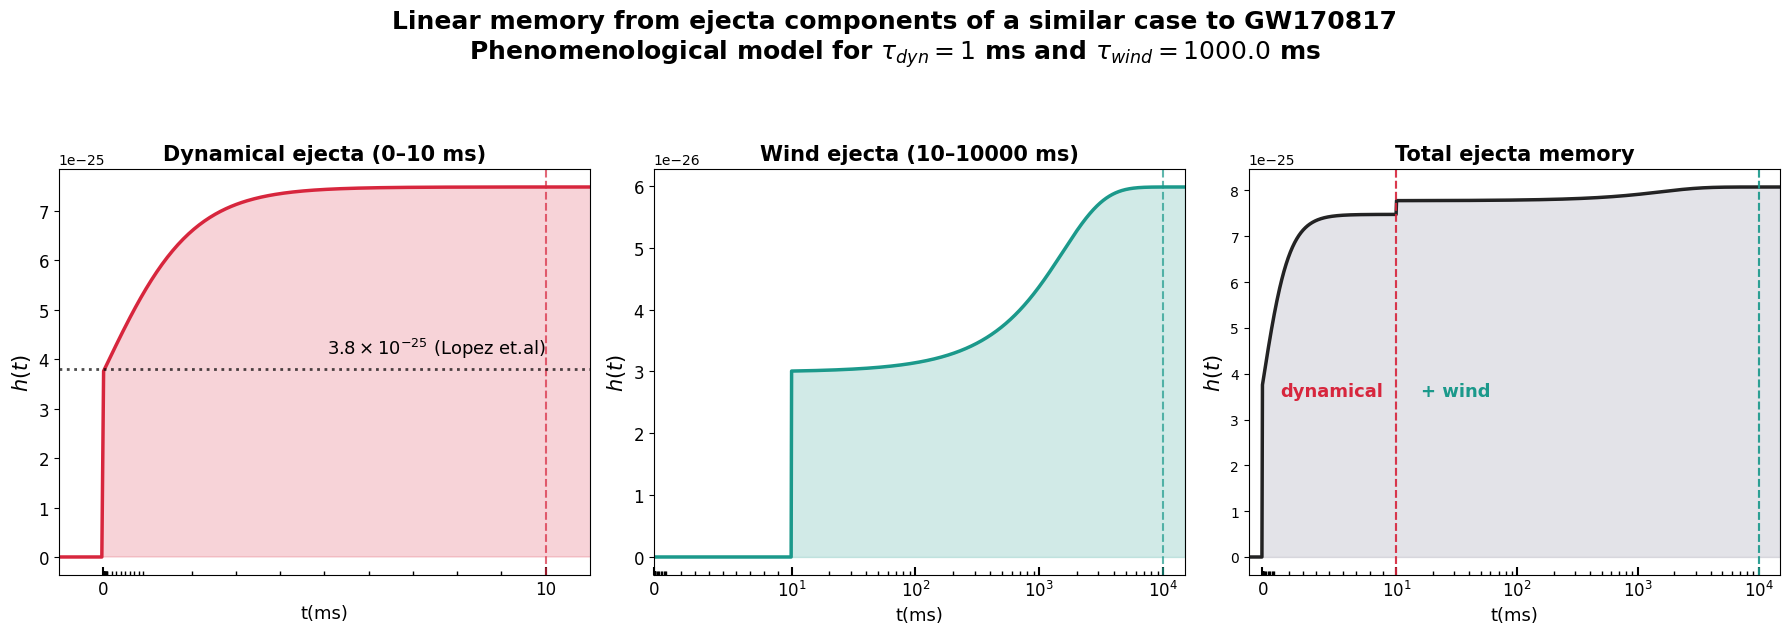

In [15]:
# Parameters 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1  

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3  

r = 40  * 1e6  
t = np.linspace(-5., 15., 500000) * 1e3  # ms

# Physically motivated time ranges for the activity of each ejecta component (to be modified according to the simulations and assumptions: EOS, mass ratio, etc)
start_dyn, end_dyn = 0, 10 
start_wind, end_wind = 10, 10e3 
up.phenom_memory_ejecta_components(
    t, M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    r, model='exponential', plot=True, save=True
)

### Comparison of the different caracteristic timescales for each ejecta component

Now we can determined how the caracteristic timescale of each ejecta component impact the total memory evolution :

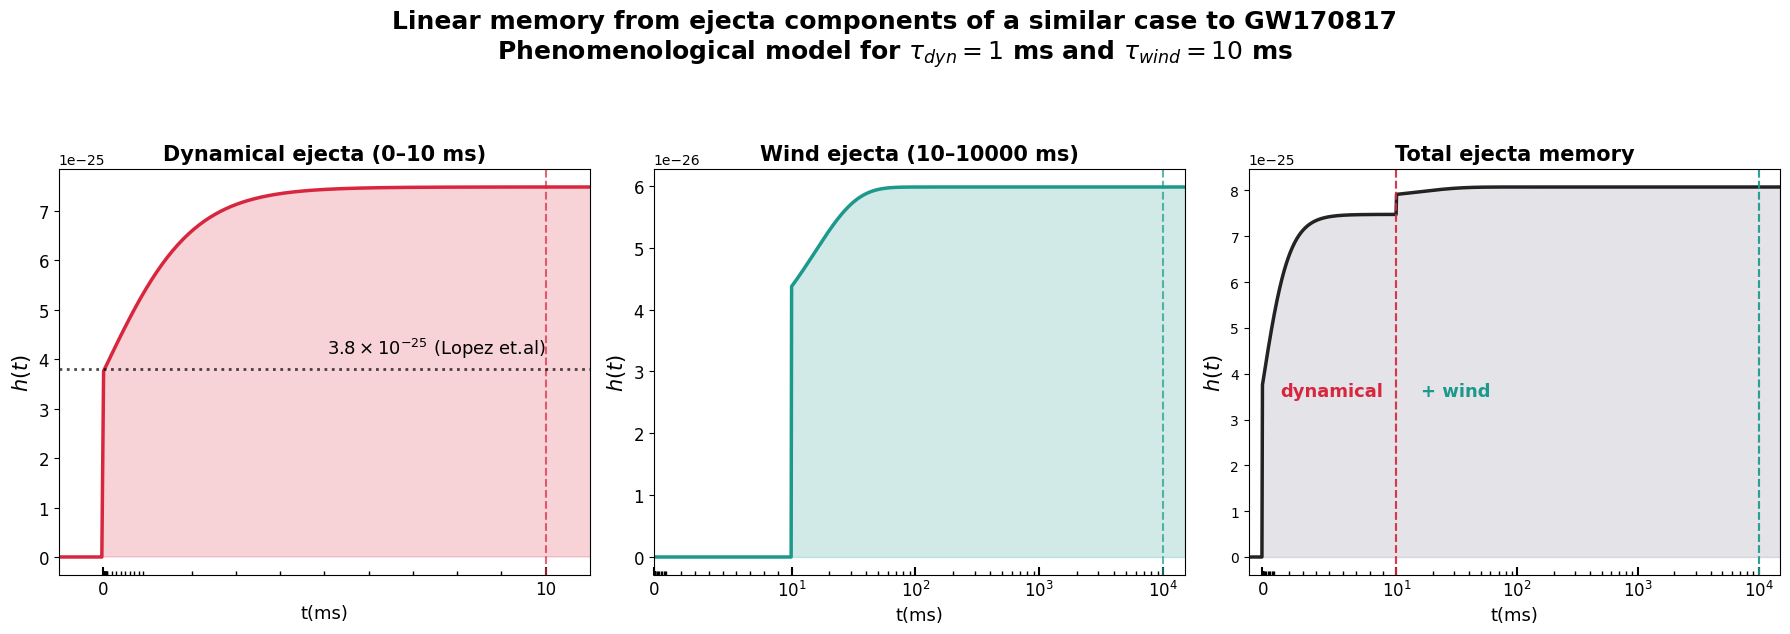

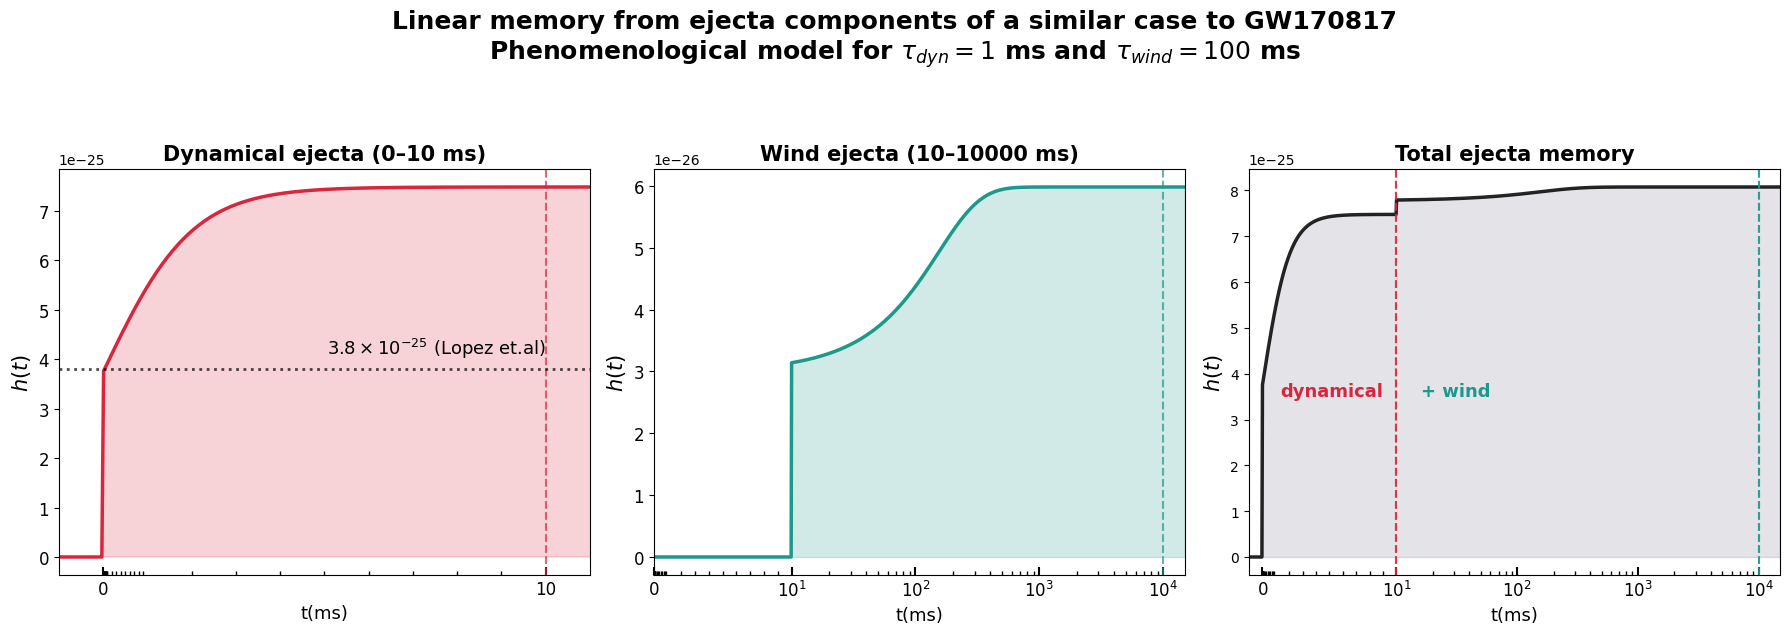

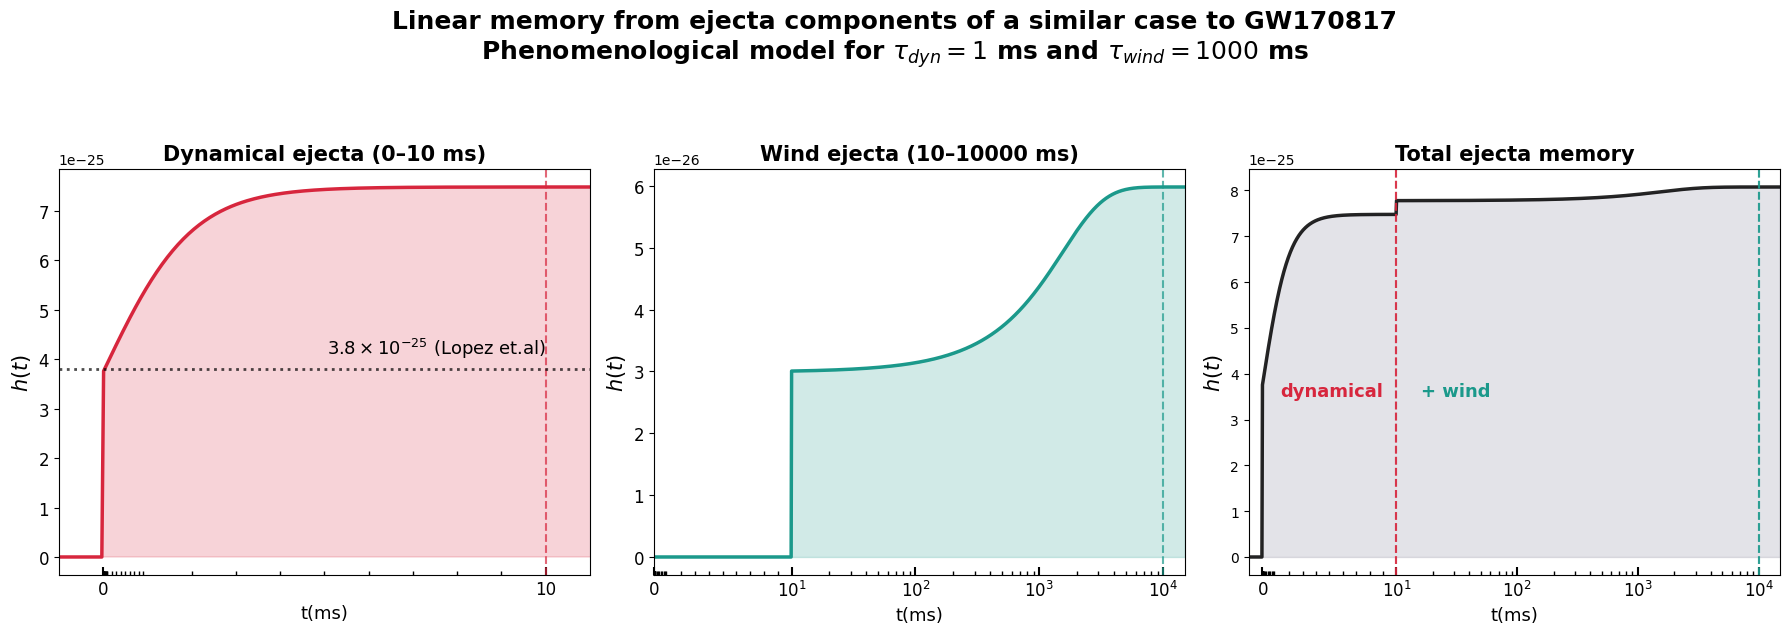

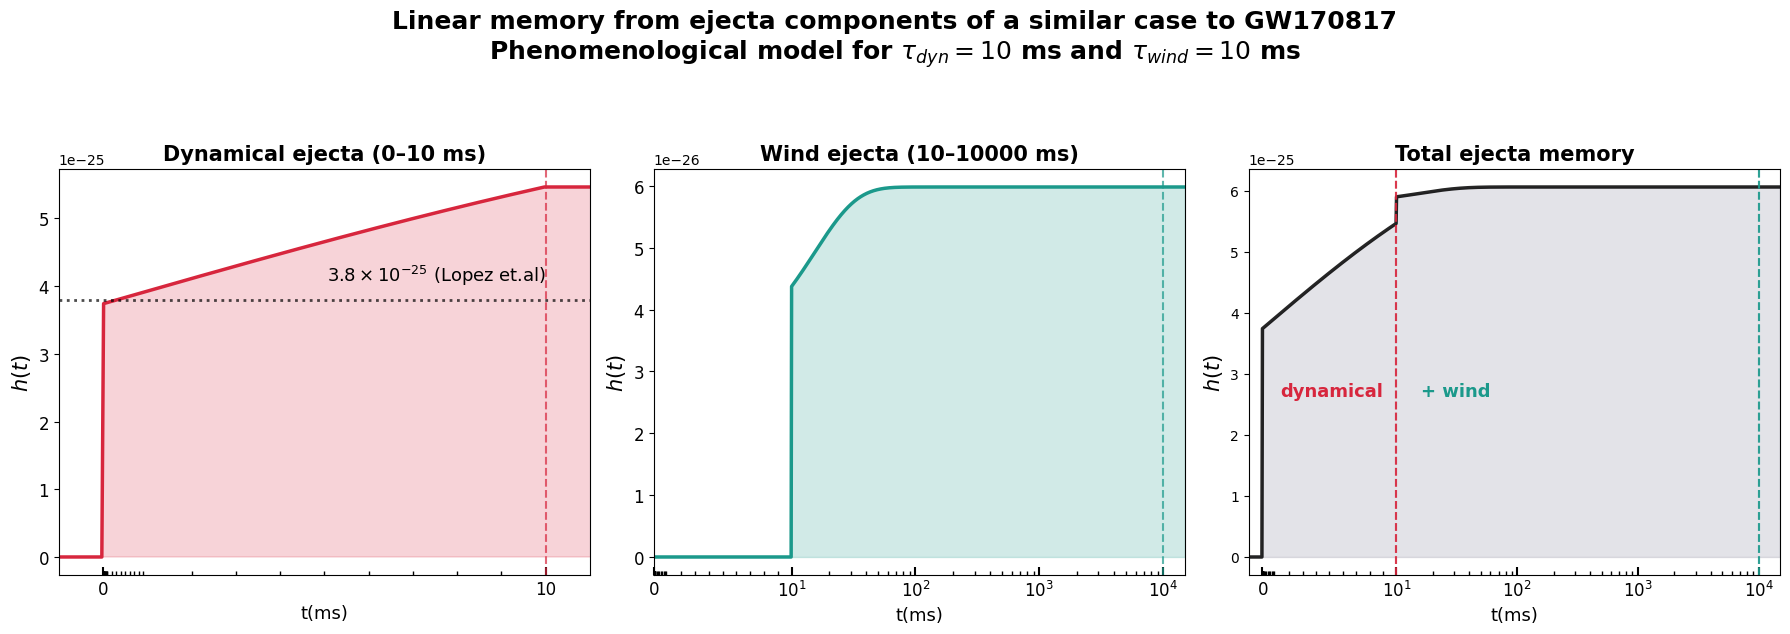

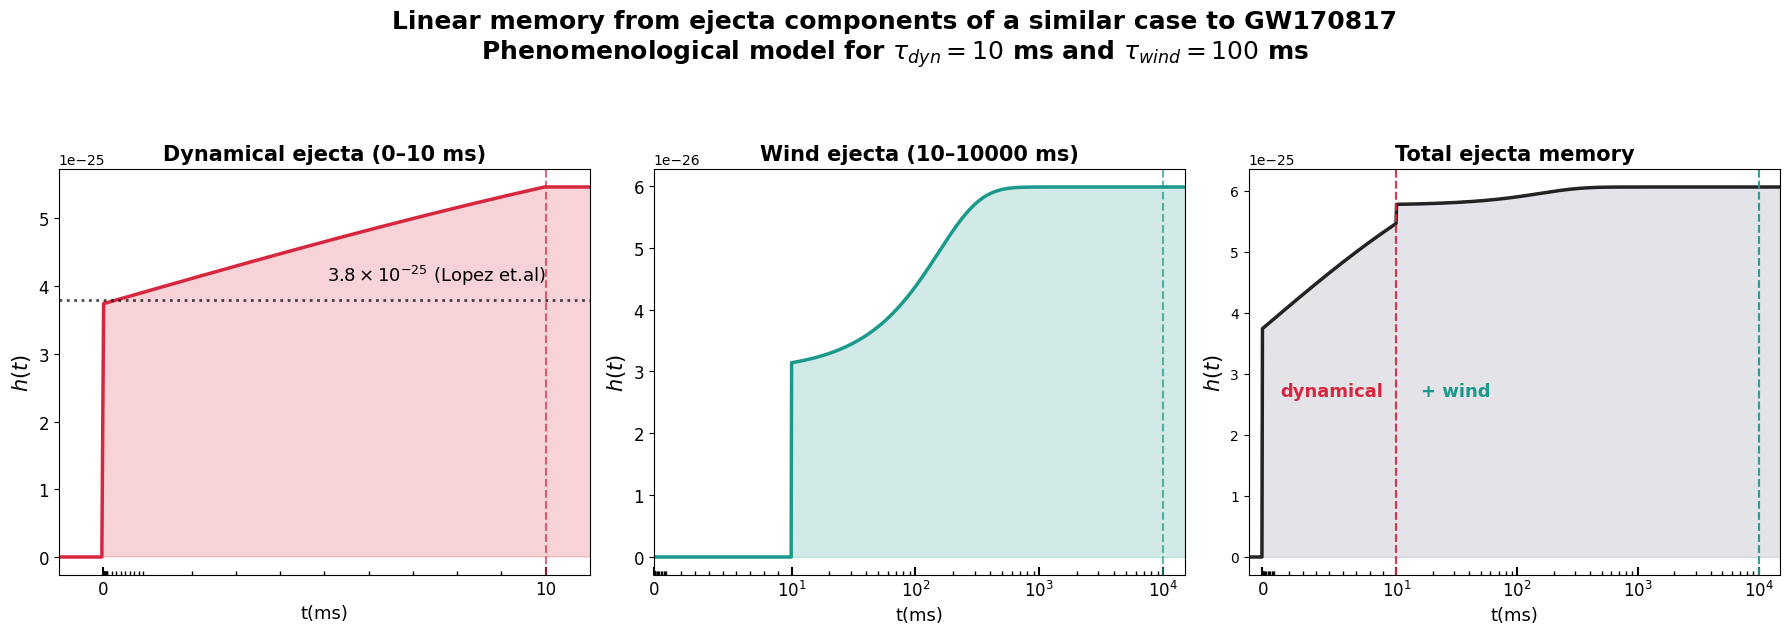

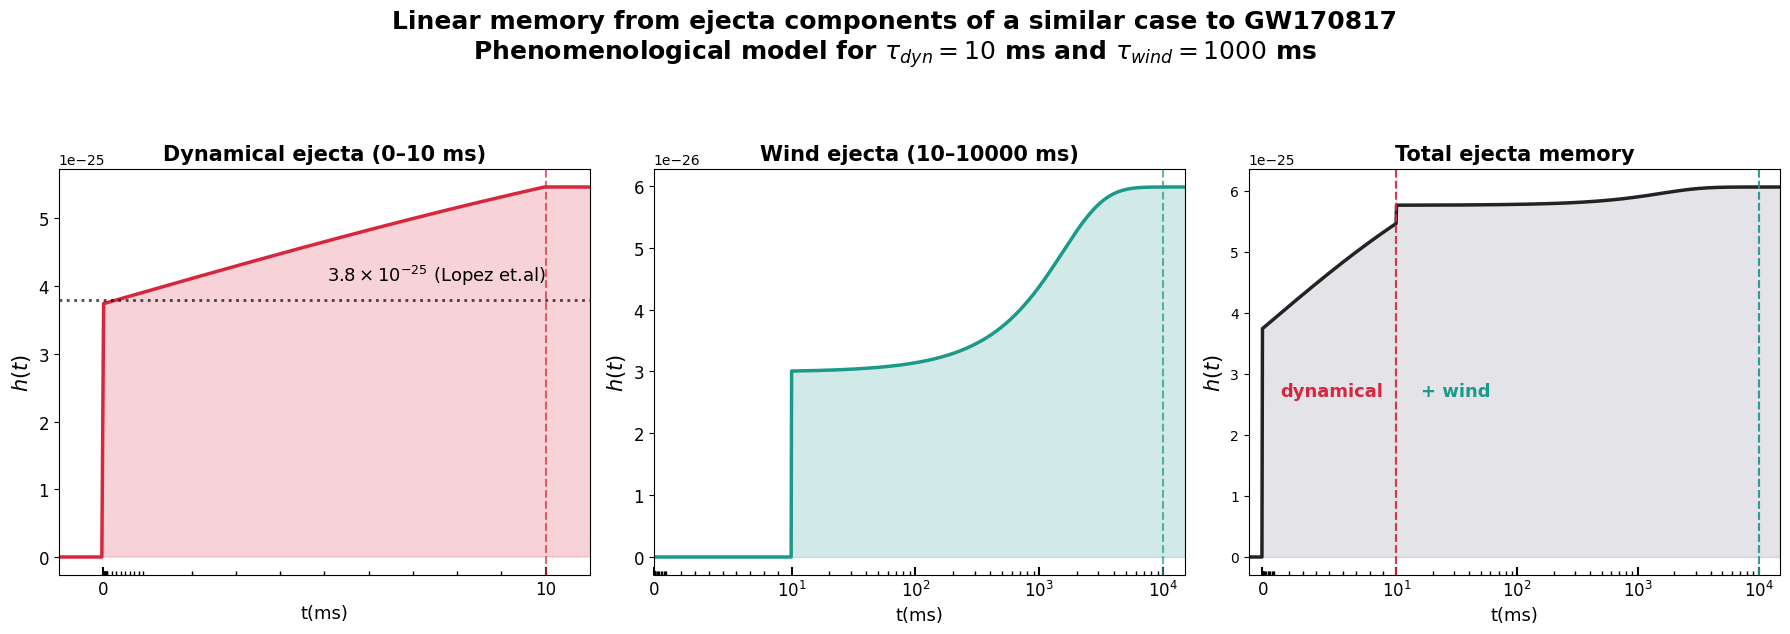

In [16]:
tau_dyn_ms = [1, 10] 
tau_wind_ms = [10,100, 1000] 
for tau_dyn in tau_dyn_ms:
    for tau_wind in tau_wind_ms:
        up.phenom_memory_ejecta_components(
            t, M_ej_dyn, v_ej_dyn, tau_dyn, start_dyn, end_dyn,
            M_ej_wind, v_ej_wind, tau_wind, start_wind, end_wind,
            r, model='exponential', plot=True, save=True)
        

GRB memory

A GRB can produce a memory signal that dependends on the release of energy $E_j$ in accelerating jets (forward and backward) with ultrarelativistic velocities. If we denode by $\beta\sim 1$ the velocity of the jets and by $\theta$ the angle between the jet axis and the line of sight, the memory signal can be estimated as  : 
$$\Delta h = \frac{2 E_j \beta^2}{r} \frac{\sin^2\theta}{1-\beta\cos\theta}$$

And it is estimated to have a caracteristic timescale of $\tau_{GRB} \sim 0.2 - 3$ ms (source ? https://arxiv.org/pdf/1201.4431 - conclusion a.), depending on the opening angle and composition of the jet(Lopez et al.). We can then apply the same phenomenological model as for the ejecta, but with this new timescale and a different amplitude. We can also add this contribution to the total memory from the ejecta. For the case of GRB170817A, the energy released in the jet is estimated to be $E_j \sim 10^{47}$ erg, which is much lower than the typical energy released in a GRB ($\sim 10^{51}$ erg). This is because GRB170817A was observed off-axis, with an angle of $\theta \sim 30$ degrees. The associated GRB is denoted as a sGRB, lasting ~2 s. 

Does the factor 2 is related to the fact that there are 2 jets (forward and backward) ?

I added a factor of $G/c^4$ in front of $\Delta h$ to make the amplitude of the GRB an adimensional strain.

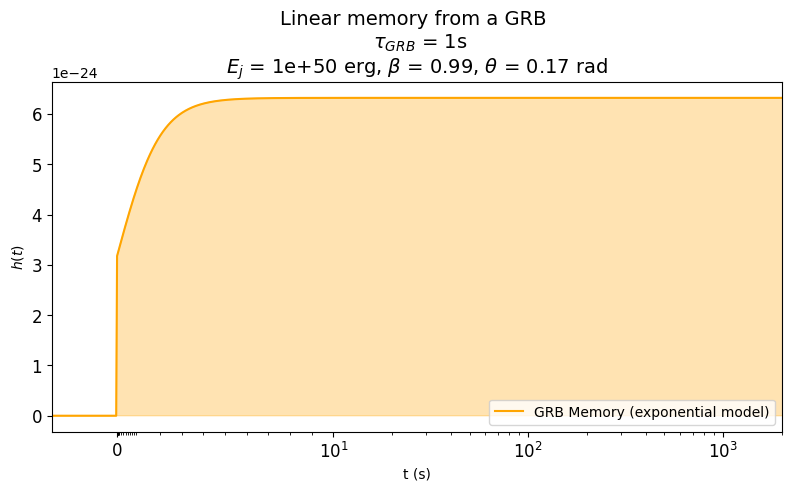

In [71]:
# Parameters for GRB memory
E_erg = 1e50  # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(10)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
r = 1  * 1e6  # parsecs
t = np.linspace(-5., 15., 500000) * 1e3  # ms
start_GRB, end_GRB = 0, 2000 # end GRB at 2s, which is the duration of the associated sGRB ?? (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
_= up.phenom_memory_GRB(t, E_erg, beta, theta, r, tau_grb_ms, start_GRB, end_GRB, model='exponential', plot=True)


We observe that the GRB memory has a **higher** amplitude than the ejecta memory, but a much shorter timescale. The total memory signal would then be dominated by the GRB contribution at early times, and by the ejecta contribution at later times.

The dependence in the angle $\theta$ is quite strong, so if the jet is not pointed towards us, the memory signal would be much weaker : 

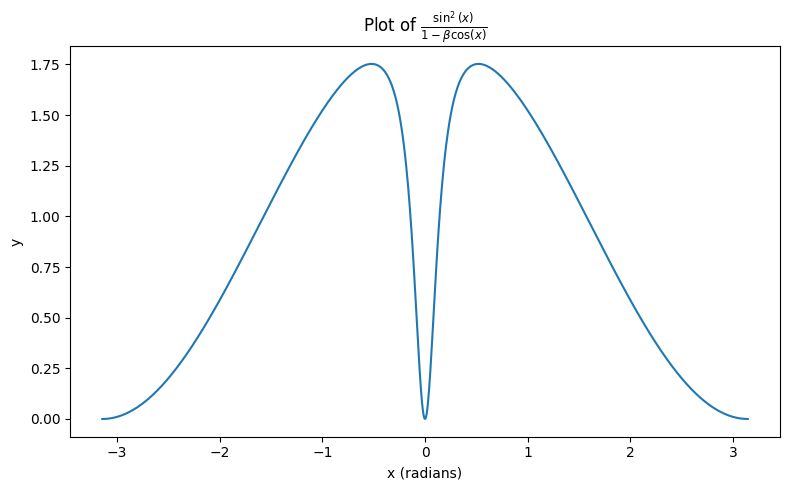

In [18]:
x = np.linspace(-np.pi, np.pi, 1000)
y = np.sin(x)**2/ (1 - 0.99* np.cos(x))

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.xlabel("x (radians)")
plt.ylabel("y")
plt.title(r"Plot of $\frac{\sin^2(x)}{1- \beta \cos(x)}$")
plt.tight_layout()
plt.savefig(out_dir + "angular_depedancy_grb.png")
plt.show()

Add the GRB memory to the total memory from the ejecta (dynamical + wind + GRB)

/home/pycbc/work/Memory_Lopez/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return delta_h / (1 + np.exp(-t / tau))


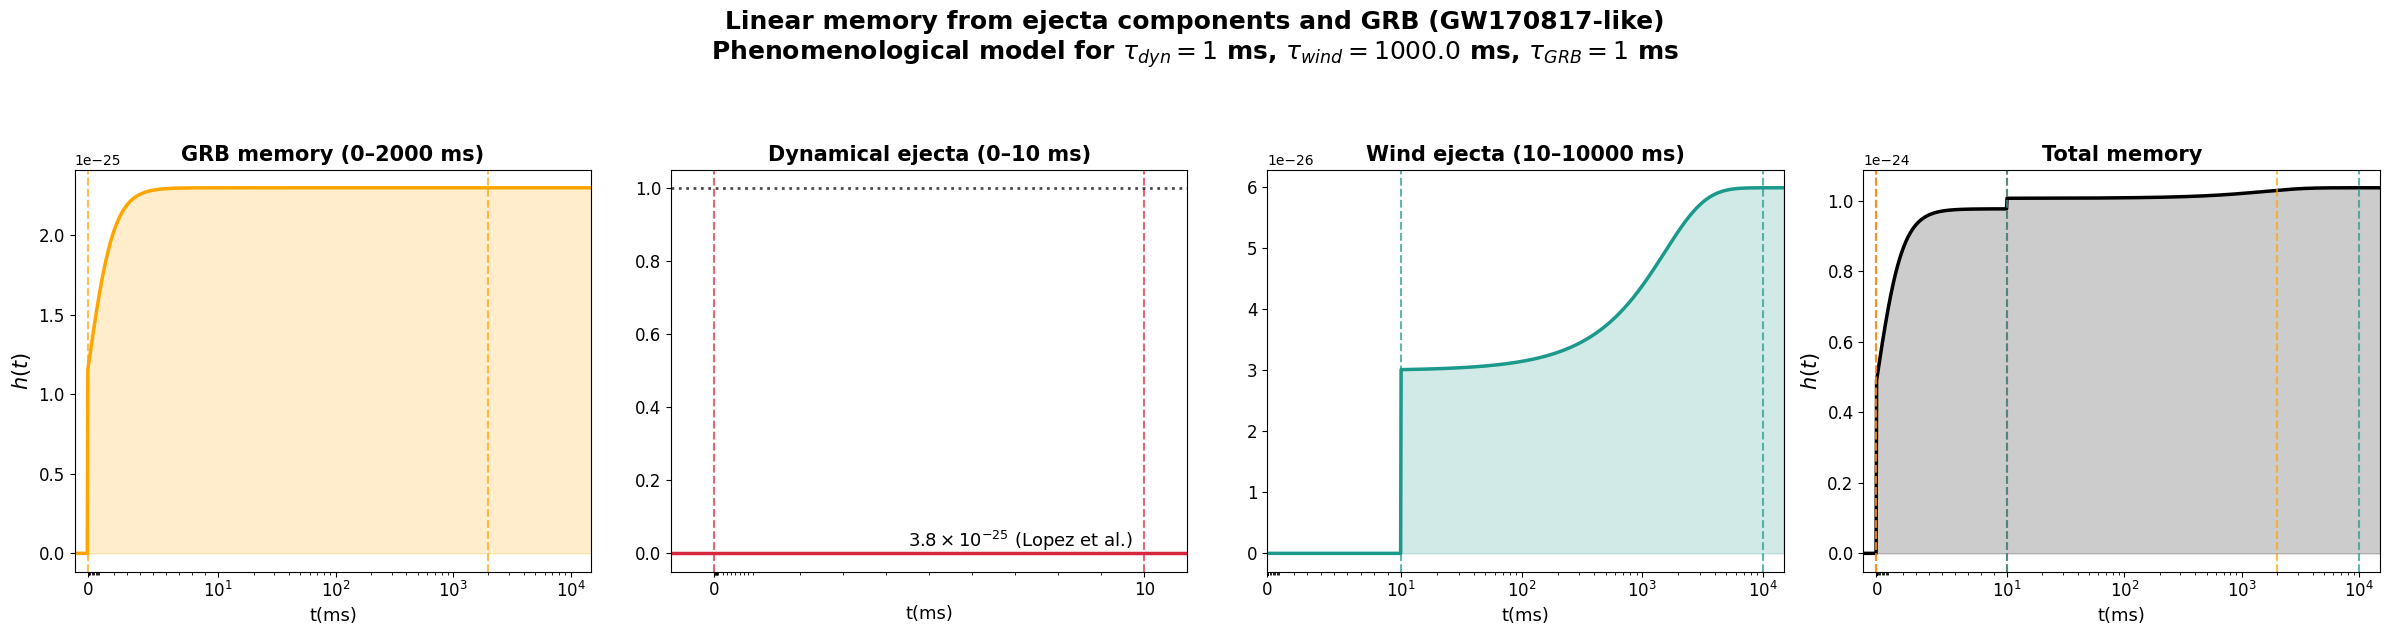

In [2]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e50   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 2000 # end GRB at 2s, which is the duration of the associated sGRB ?? 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1 

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 40  * 1e6  # 170817
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3

up.phenom_memory_ejecta_components_GRB(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb, 
    save=True
)

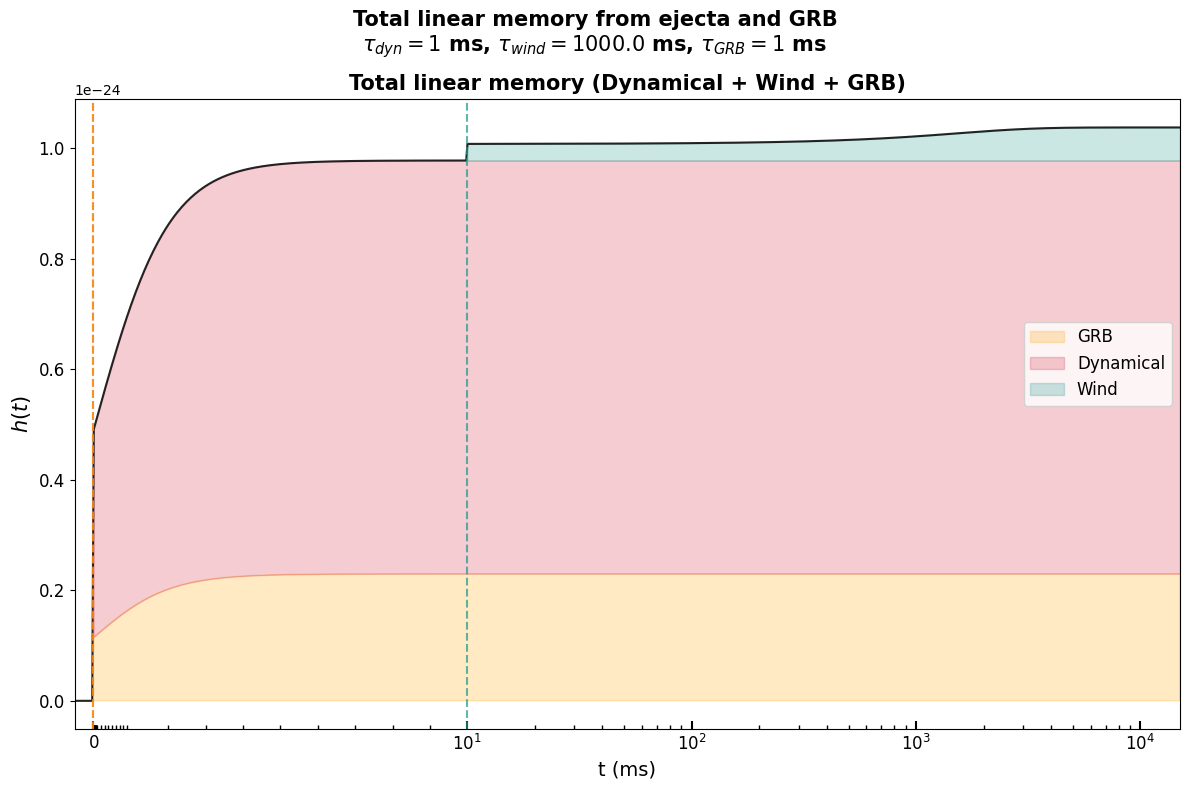

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       1.03750085e-24, 1.03750085e-24, 1.03750085e-24])

In [3]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e50   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 2000 # end GRB at 2s, which is the duration of the associated sGRB ?? 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 40  * 1e6  # 170817
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3
up.phenom_memory_total_plot(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb,
    save = True
    
)

Test BOAT

/home/pycbc/work/Memory_Lopez/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return delta_h / (1 + np.exp(-t / tau))


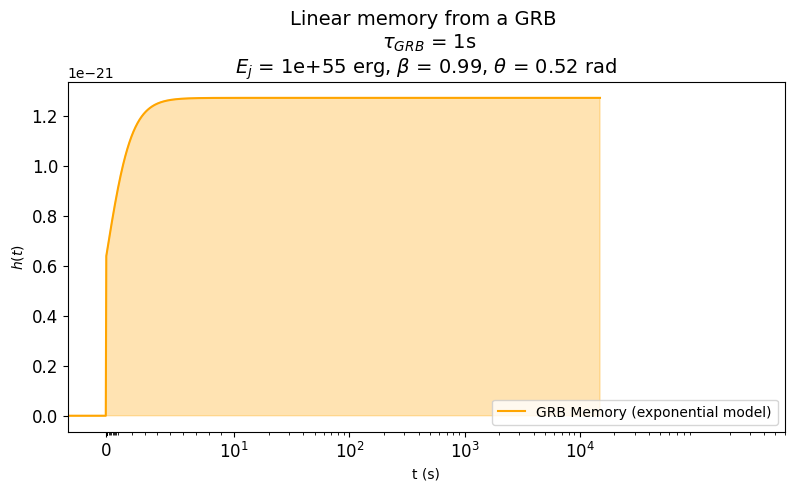

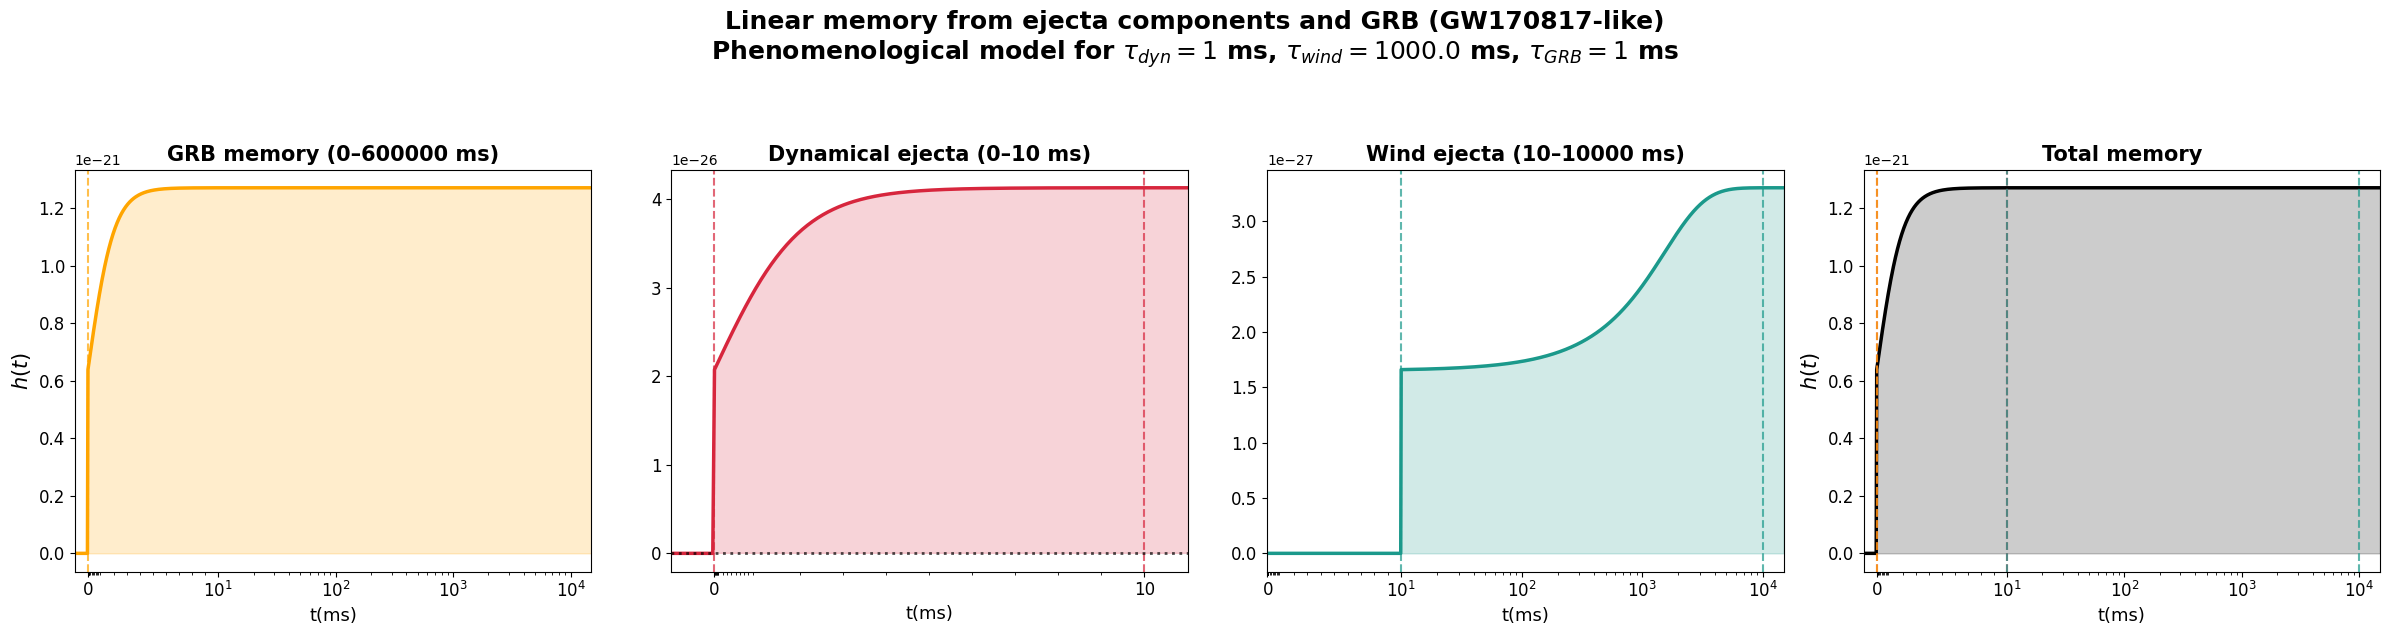

In [5]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 600*1e3 # end GRB at 600s 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1 

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 724  * 1e6  #BOAT
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3

up.phenom_memory_GRB(t, E_j, beta, theta, r, tau_grb_ms, start_grb, end_grb, model='exponential', plot=True)

up.phenom_memory_ejecta_components_GRB(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb,
    delta_h_typical=False, save = True)


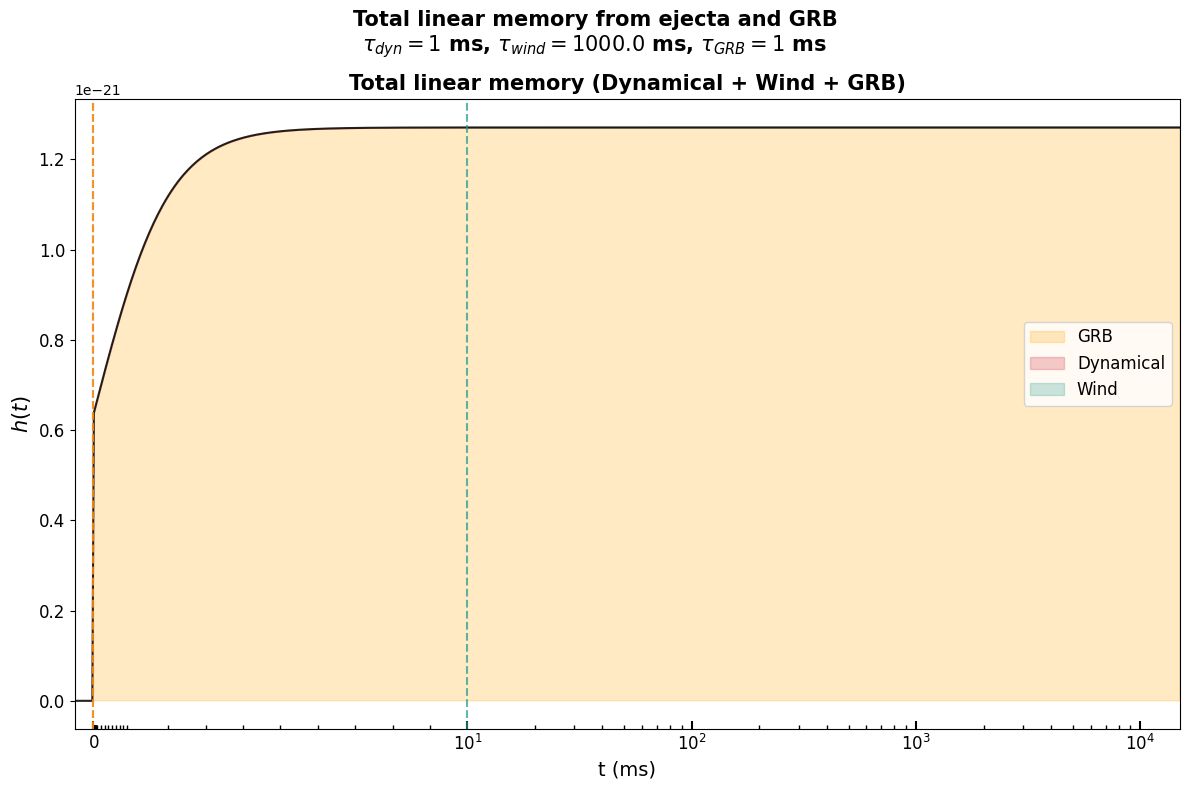

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       1.27076075e-21, 1.27076075e-21, 1.27076075e-21])

In [23]:
# Parameters for GRB memory
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 600*1e3 # end GRB at 600s 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
# Parameters for the combined memory from ejecta (dynamical + wind) 
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r_BOAT = 724 * 1e6  # BOAT
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3
up.phenom_memory_total_plot(
    t,
    r,
    M_ej_dyn, v_ej_dyn, tau_dyn_ms, start_dyn, end_dyn,
    M_ej_wind, v_ej_wind, tau_wind_ms, start_wind, end_wind,
    E_j, beta, theta, tau_grb_ms, start_grb, end_grb,
    save = True
)

## Test with different parameters for the GRB memory

/home/pycbc/work/Memory_Lopez/utils_phenom.py:15: RuntimeWarning: overflow encountered in exp
  return delta_h / (1 + np.exp(-t / tau))


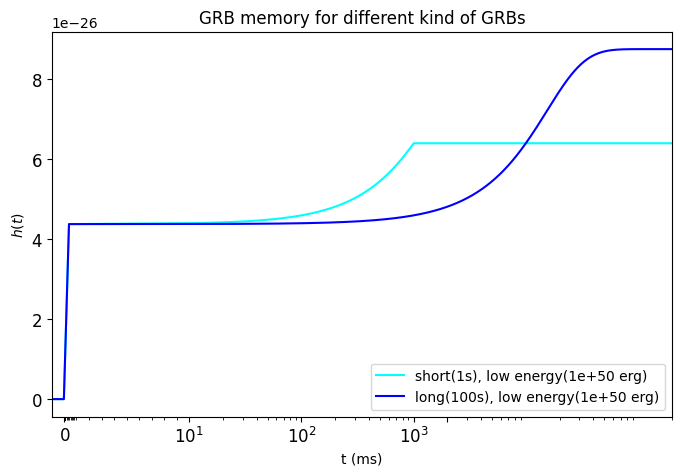

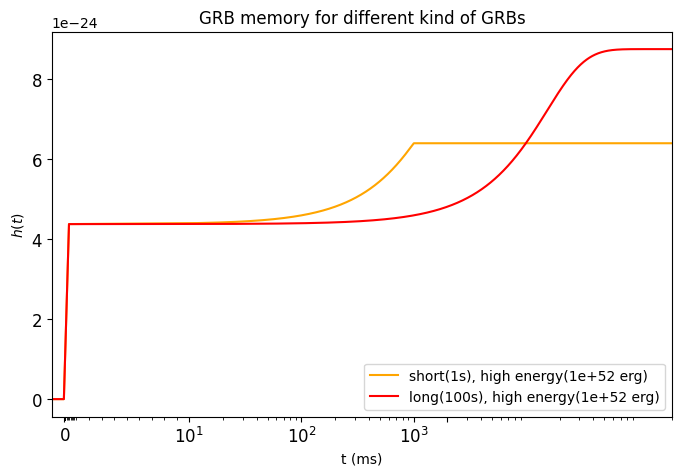

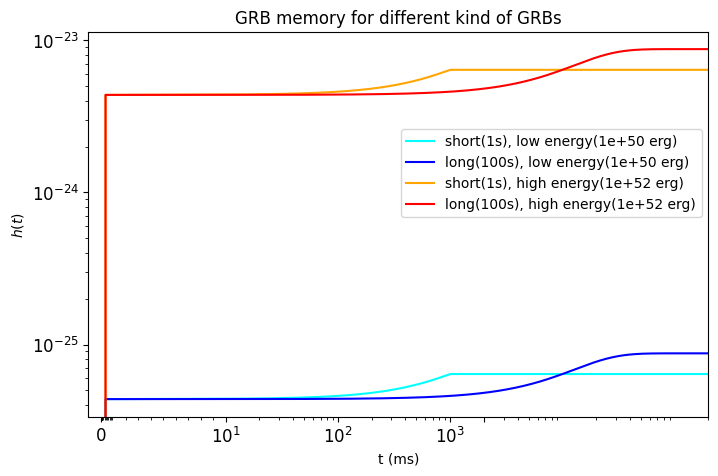

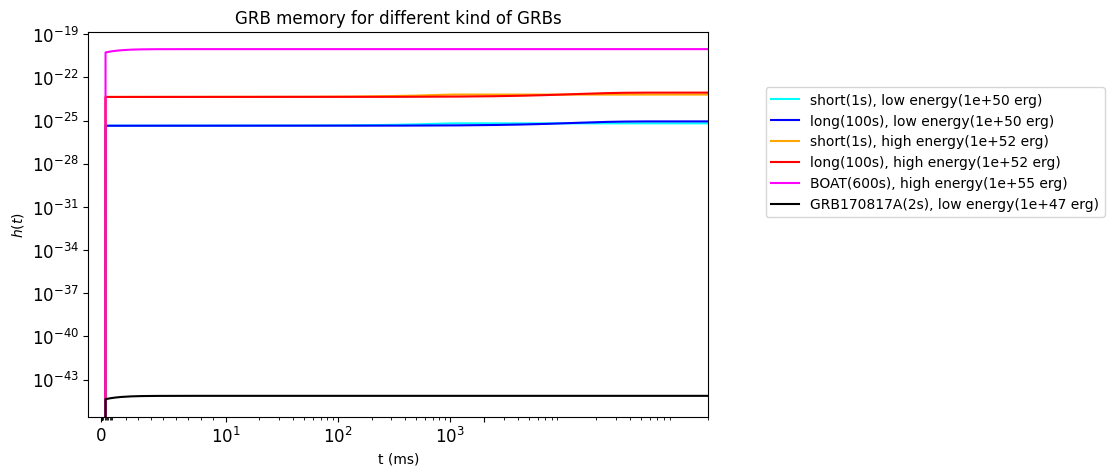

In [59]:
from matplotlib.ticker import FixedLocator, LogLocator
# test for a short low energetic GRB, short and higly energetic GRB, and a long GRB with low and high energy
# we test 4 cases 
t = np.linspace(-5., 200., 500000) * 1e3  # ms
r = 100 * 1e6  # 100 Mpc
# short : 1s -- long: 100s
end_grb = np.array([1, 100]) * 1e3 # s
# low energy: 1e49 erg -- high energy: 1e52 erg
energy = np.array([1e50, 1e52])  # erg
theta = np.deg2rad(45)  # 45 degrees off axis - tradeoff between detectability and rate
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = np.array([1, 10]) *1e3  # s
start_grb = 0
h_grb = []
cases =[
    {"energy": energy[0], "end_grb": end_grb[0], "label": "short" + f'({end_grb[0]/1000:.0f}s)'+", low energy"+ f'({energy[0]:.0e} erg)', 'color': 'cyan'},
    {"energy": energy[0], "end_grb": end_grb[1], "label": "long" + f'({end_grb[1]/1000:.0f}s)'+", low energy"+ f'({energy[0]:.0e} erg)', 'color': 'blue'},
    {"energy": energy[1], "end_grb": end_grb[0], "label": "short" + f'({end_grb[0]/1000:.0f}s)'+", high energy"+ f'({energy[1]:.0e} erg)', 'color': 'orange'},
    {"energy": energy[1], "end_grb": end_grb[1], "label": "long" + f'({end_grb[1]/1000:.0f}s)'+", high energy"+ f'({energy[1]:.0e} erg)', 'color': 'red'},
]
for e in energy:
    for end, tau in zip(end_grb, tau_grb_ms):
        h_grb.append(up.phenom_memory_GRB(
            t, e, beta, theta, r, tau, start_grb, end, model='exponential', plot=False))
        
# BOAT case 
E_j_boat = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta_boat = np.deg2rad(30)  # 30 degrees off axis
beta_boat = 0.99  # ultrarelativistic jet
tau_grb_boat_ms = 1  # ms
start_grb_boat, end_grb_boat = 0, 600*1e3 # end GRB at 600s 
# (seems long for the memory case, I would expect something more similar to the dynamical ejecta timescale)
h_boat = up.phenom_memory_GRB(
    t, E_j_boat, beta_boat, theta_boat, r, tau_grb_boat_ms, start_grb_boat, end_grb_boat, model='exponential', plot=False)
# Plot short GRBs (1s, low and high energy)

# 170817 case
E_j_170817 = 1e47   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta_170817 = np.deg2rad(30)  # 30 degrees off axis
beta_170817 = 0.99  # ultrarelativistic jet
tau_grb_170817_ms = 1  # ms
start_grb_170817, end_grb_170817 = 0, 2000
r_170817 = 40 * PC_SI * 1e6  # 170817
h_170817 = up.phenom_memory_GRB(
    t, E_j_170817, beta_170817, theta_170817, r_170817, tau_grb_170817_ms, start_grb_170817, end_grb_170817, model='exponential', plot=False)

plt.figure(figsize=(8, 5))
for i in [0,1]:  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right")
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()

plt.figure(figsize=(8, 5))
for i in [2,3]:  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right")
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()


plt.figure(figsize=(8, 5))
for i in range(4):  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right", bbox_to_anchor=(1.0, 0.5))
plt.yscale('log')
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)
from matplotlib.ticker import FixedLocator, LogLocator
ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()

plt.figure(figsize=(8, 5))
for i in range(4):  # indices for short GRBs
    plt.plot(t, h_grb[i], label=cases[i]['label'], color=cases[i]['color'])
plt.plot(t, h_boat, label='BOAT' + f'({end_grb_boat/1000:.0f}s)'+", high energy"+ f'({E_j_boat:.0e} erg)', color='magenta')
plt.plot(t, h_170817, label='GRB170817A' + f'({end_grb_170817/1000:.0f}s)'+", low energy"+ f'({E_j_170817:.0e} erg)', color='black')
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("GRB memory for different kind of GRBs")
plt.legend(loc = "lower right", bbox_to_anchor=(1.65, 0.5))
plt.yscale('log')
plt.xlim(-1, 200e3)  # focus on the first 200s
plt.xscale('symlog', linthresh=10, linscale=1.0)

plt.tick_params(axis='both', labelsize=12)
from matplotlib.ticker import FixedLocator, LogLocator
ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([0,10,100,1000,2000]))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs='auto'))
plt.show()



## FFT of the different memory contributions

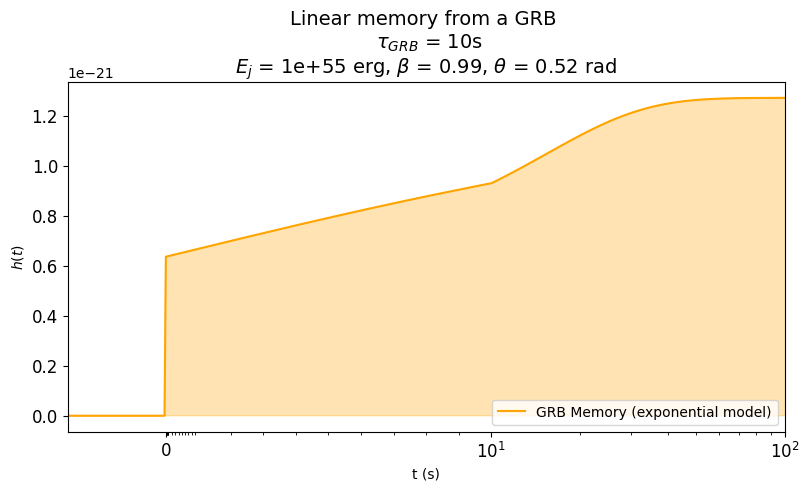

In [60]:
# BOAT case : 
t = np.linspace(-5., 15., 500000) * 1e3  # ms
E_j_boat = 1e55   # https://iopscience.iop.org/article/10.3847/2041-8213/accf93/pdf brightest object
theta_boat = np.deg2rad(30)  # 30 degrees off axis
beta_boat = 0.99  # ultrarelativistic jet
tau_grb_boat_s = 10 # s
r_boat = 724 * 1e6  # BOAT
start_grb_boat, end_grb_boat = 0, 600*1e3 # end GRB at 600s 

up.phenom_memory_GRB(t, E_j_boat, beta_boat, theta_boat, r_boat, tau_grb_boat_s, start_grb_boat, 1e2, model='exponential', plot=True)
h_BOAT = up.phenom_memory_GRB(
    t, E_j_boat, beta_boat, theta_boat, r_boat, tau_grb_boat_ms, start_grb_boat, end_grb_boat, model='exponential', plot=False)

In [61]:
# GW170817 case
E_j_170817 = 1e47   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta_170817 = np.deg2rad(30)  # 30 degrees off axis
beta_170817 = 0.99  # ultrarelativistic jet
tau_grb_170817_ms = 1  # ms
start_grb_170817, end_grb_170817 = 0, 2000
r_170817 = 40 * 1e6 

# Ejecta parameters for GW170817
M_ej_dyn = 0.04  # solar masses
v_ej_dyn = 0.2   # m/s
tau_dyn_ms = 1  # ms

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3
h_170817_grb = up.phenom_memory_GRB(
    t, E_j_170817, beta_170817, theta_170817, r_170817, tau_grb_170817_ms,
    start_grb_170817, end_grb_170817, model='exponential', plot=False)
h_170817_dyn = up.linear_memory_ejecta_masked(t, M_ej_dyn, v_ej_dyn,tau_dyn_ms, r_170817, start_dyn, end_dyn, model='exponential')
h_170817_wind = up.linear_memory_ejecta_masked(t, M_ej_wind, v_ej_wind, tau_wind_ms, r_170817, start_wind, end_wind, model='exponential')
h_170817_total = h_170817_grb + h_170817_dyn + h_170817_wind


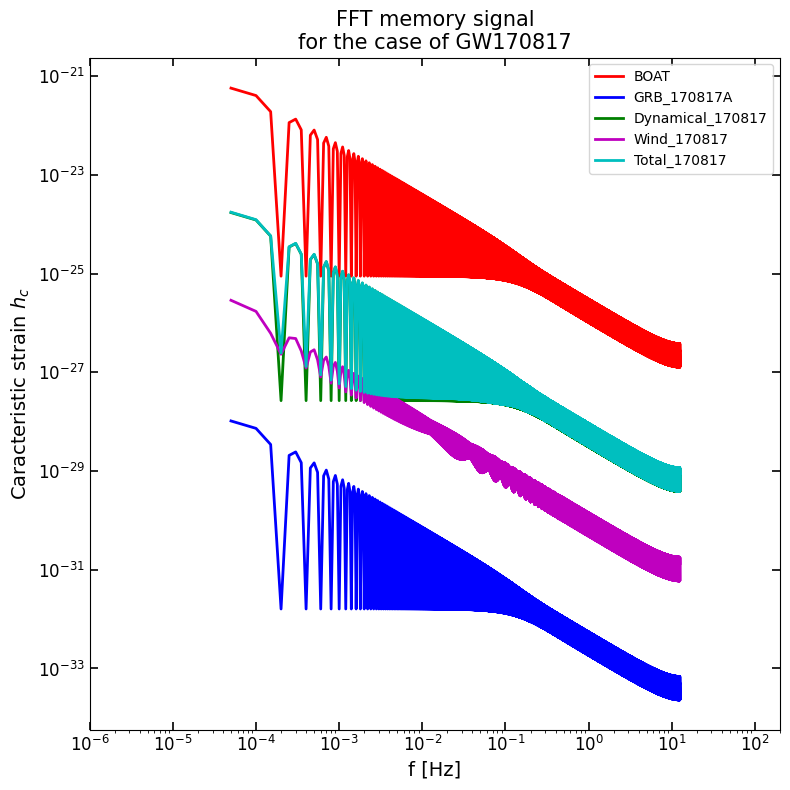

In [62]:
# FFT plot
h_list = [h_BOAT, h_170817_grb, h_170817_dyn, h_170817_wind, h_170817_total]
labels = ['BOAT', 'GRB_170817A', 'Dynamical_170817', 'Wind_170817', 'Total_170817']
up.memory_fft_phenom(t, h_list, labels= labels, plot=True, show=True, add_info_title='for the case of GW170817')


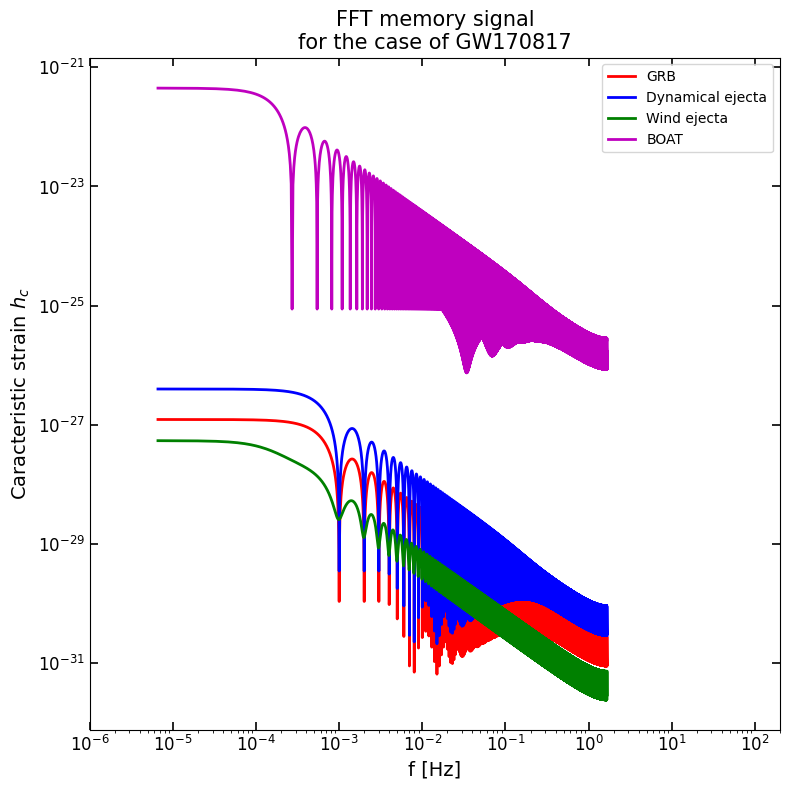

In [63]:
# Let's generate different GRB memory and dynamical/wind ejecta memory

t = np.linspace(-1., 150., 500000) * 1e3  # ms

E_j = 1e50   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  # 30 degrees off axis
beta = 0.99  # ultrarelativistic jet
tau_grb_ms = 1  # ms
start_grb, end_grb = 0, 2000  
M_ej_dyn = 0.5*1e-2 
v_ej_dyn = 0.25 
tau_dyn_ms = 1

M_ej_wind = 0.01 
v_ej_wind = 0.05 
tau_wind_ms = 1e3
r = 100  * 1e6  
start_dyn, end_dyn = 0, 10
start_wind, end_wind = 10, 10e3


h_grb = up.phenom_memory_GRB(
    t, E_j, beta, theta, r, tau_grb_ms, start_grb, end_grb, model='exponential', plot=False)
h_dyn = up.linear_memory_ejecta_masked(t, M_ej_dyn, v_ej_dyn, tau_dyn_ms, r, start_dyn, end_dyn, model='exponential')
h_wind = up.linear_memory_ejecta_masked(t, M_ej_wind, v_ej_wind, tau_wind_ms, r, start_wind, end_wind, model='exponential')

# FFT plot
h_list = [h_grb, h_dyn, h_wind, h_boat]
labels = ['GRB', 'Dynamical ejecta', 'Wind ejecta', 'BOAT']
up.memory_fft_phenom(t, h_list, labels= labels, plot=True, show=True, add_info_title='for the case of GW170817')



Now applying a window

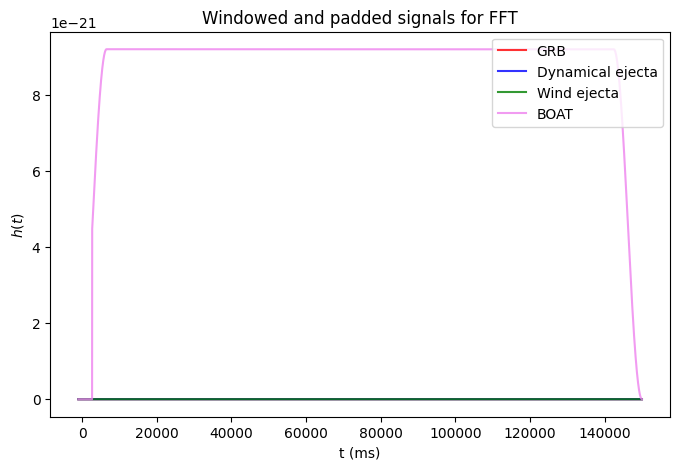

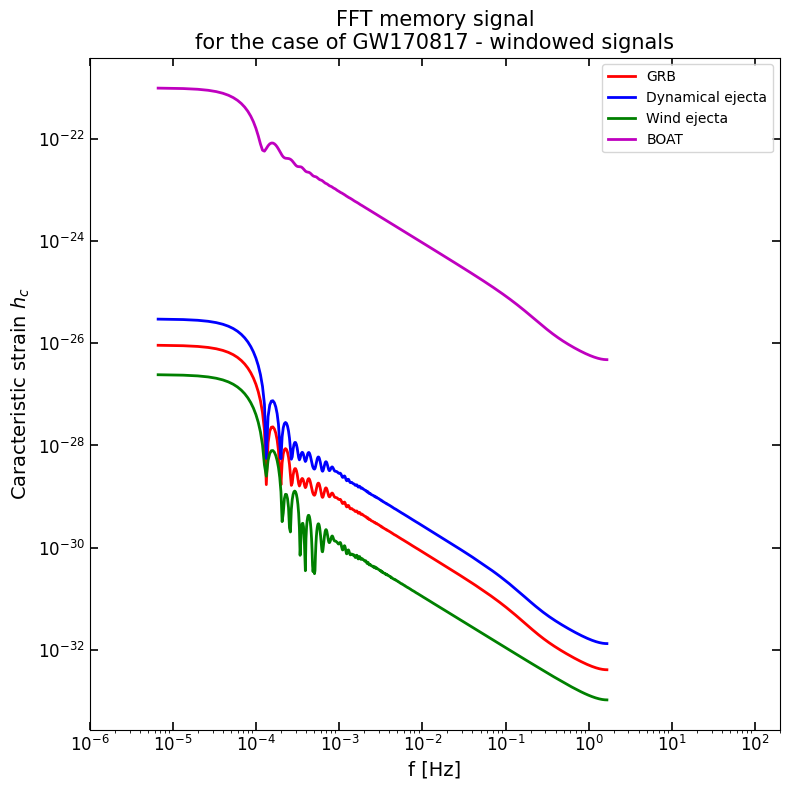

In [64]:
h_windowed=[]
colors = ['r', 'b', 'g', 'violet']
plt.figure(figsize=(8, 5))
for idx, h in enumerate(h_list):
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)
    plt.plot(t, h_w, label=labels[idx],c = colors[idx], alpha=0.8)
plt.xlabel("t (ms)")
plt.ylabel(r"$h(t)$")
plt.title("Windowed and padded signals for FFT")
plt.legend(loc= 'upper right')
plt.show()

up.memory_fft_phenom(t, h_windowed, labels= labels, plot=True, show=True, add_info_title='for the case of GW170817 - windowed signals')


LISA sensitivity curve found on https://github.com/eXtremeGravityInstitute/LISA_Sensitivity and associated paper https://arxiv.org/pdf/1803.01944

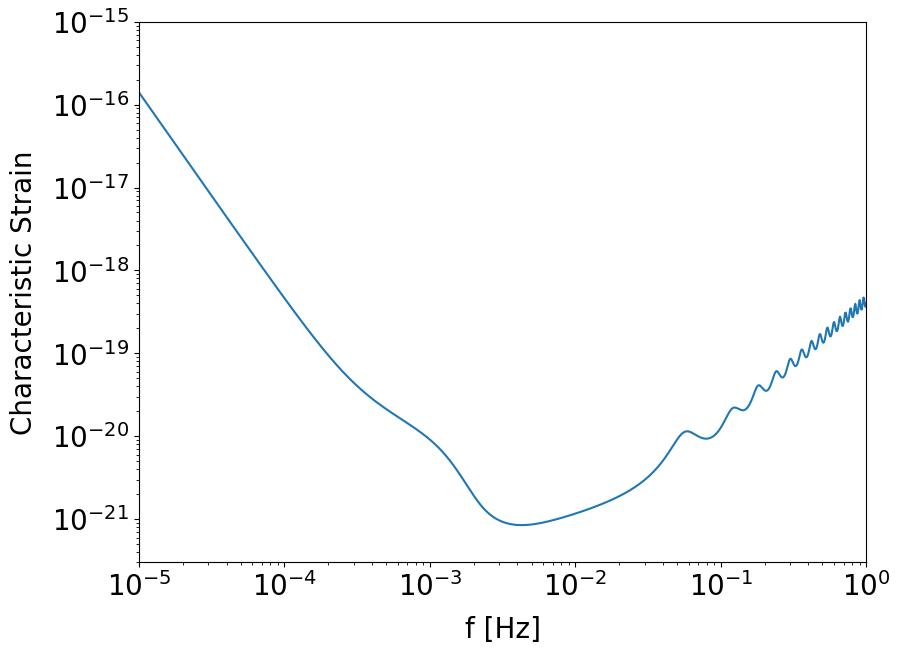

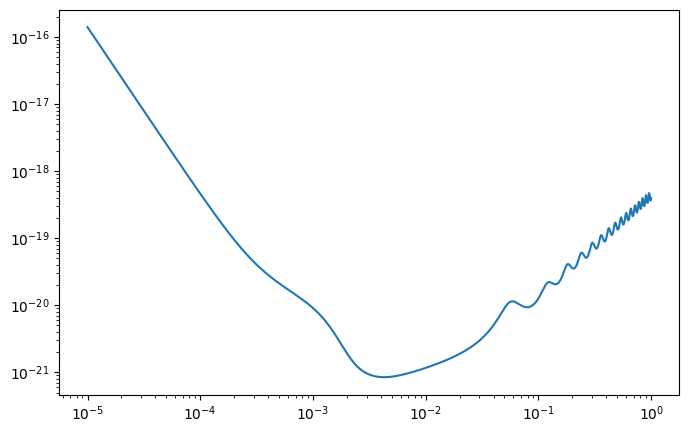

In [107]:
import LISA as li
lisa = li.LISA() # initialize LISA object

f  = np.logspace(np.log10(1.0e-5), np.log10(1.0e0), 1000)
Sn = lisa.Sn(f)
# Plot with the function from LISA module
li.PlotSensitivityCurve(f, Sn)
# Or we can do it ourselves - The same way as in the LISA.py
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(f, np.sqrt(f*Sn))

Now we add the sensitivity curve and check if the memory signal is above the sensitivity curve of LISA. for the case of 170817

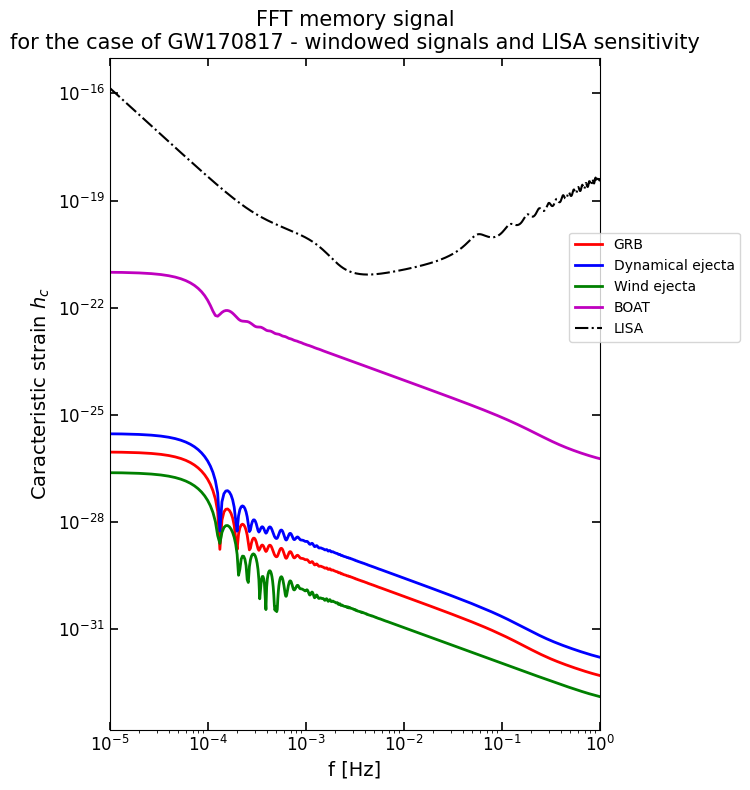

In [66]:
# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g', 'violet']
for idx, h in enumerate(h_list): # exclude the sensitivity curve from the windowing of course
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)

# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and LISA sensitivity',
    return_fig=True
)
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.75), ncol= 1)
ax.set_xlim(1e-5, 1)
fig.tight_layout()
fig.savefig(out_dir + "fft_memory_phenom_with_LISA.png")
plt.show()

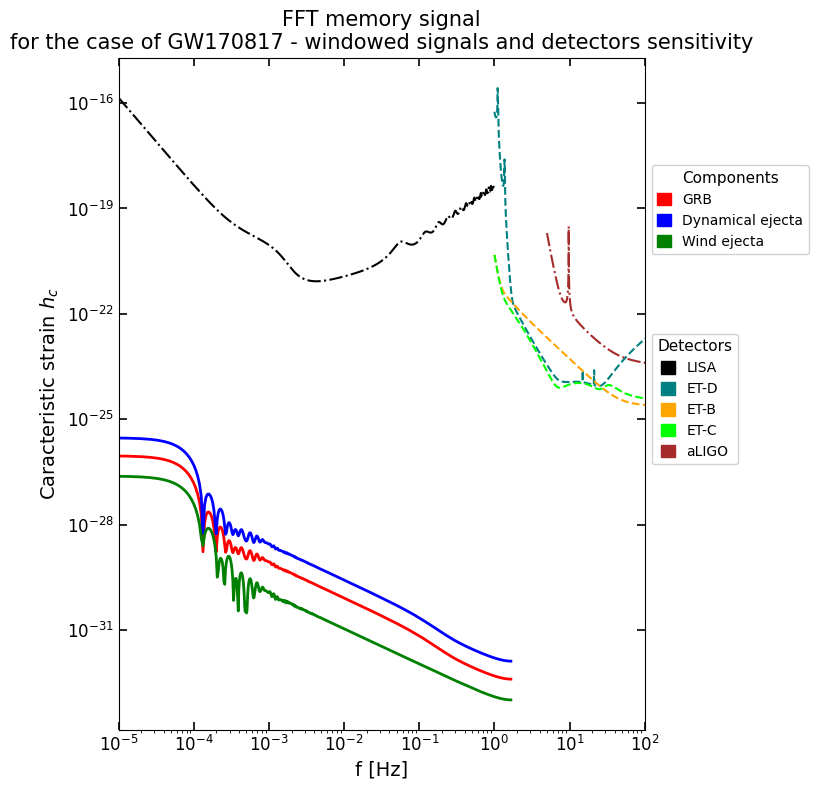

In [67]:
h_list = [h_grb, h_dyn, h_wind]
labels = ['GRB', 'Dynamical ejecta', 'Wind ejecta', 'LISA sensitivity']


# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g']
for idx, h in enumerate(h_list): # exclude the sensitivity curve from the windowing of course
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)

# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and detectors sensitivity',
    return_fig=True
)
# ---
# HERE IT IS NEW 
# ---
# Remove the legend to make a new one
ax.get_legend().remove()

# handles for the components represented by a square in the legend
import matplotlib.patches as mpatches

# Créer les handles pour les composantes avec des carrés (patches)
component_handles = [
    mpatches.Patch(color='r', label='GRB'),
    mpatches.Patch(color='b', label='Dynamical ejecta'),
    mpatches.Patch(color='g', label='Wind ejecta')
]

# LISA
ax.loglog(f, np.sqrt(f*Sn), color='k', linestyle='-.', linewidth=1.5)

# ET sensitivity curves for 3 configurations
et_sensitivities = {
    'ET-D': np.loadtxt('ET_D_sensi.txt'),
    'ET-B': np.loadtxt('ET_B_sensi.txt'),
    'ET-C': np.loadtxt('ET_C_sensi.txt')
}
et_colors = {'ET-D': 'teal', 'ET-B': 'orange', 'ET-C': 'lime'}
for label, data in et_sensitivities.items():
    ax.loglog(data[:, 0], data[:, 1], linestyle='--', color=et_colors[label], linewidth=1.5)

# aLIGO sensitivity curve
aligo_sensitivity = np.loadtxt('aLIGO_sensi.txt')
ax.loglog(aligo_sensitivity[:, 0], aligo_sensitivity[:, 1], linestyle='-.', color='brown', linewidth=1.5)

# handles for the detectors
detector_handles = [
    mpatches.Patch(color='k', label='LISA'),
    mpatches.Patch(color='teal', label='ET-D'),
    mpatches.Patch(color='orange', label='ET-B'),
    mpatches.Patch(color='lime', label='ET-C'),
    mpatches.Patch(color='brown', label='aLIGO')
]
# First one for the components

# Second for the detectors
legend1 = ax.legend(handles=detector_handles, loc='upper left',
                   bbox_to_anchor=(1., 0.6), title='Detectors',
                   fontsize=10, title_fontsize=11, framealpha=0.9,
                    handlelength=1.0, handleheight=1.0)

ax.add_artist(legend1)

legend2 = ax.legend(handles=component_handles, loc='upper left', 
                   bbox_to_anchor=(1., 0.85), title='Components',
                   fontsize=10, title_fontsize=11, framealpha=0.9,
                    handlelength=1.0, handleheight=1.0)
ax.set_xlim(1e-5, 1e2)
fig.tight_layout()
fig.savefig(out_dir + "fft_memory_phenom_with_LISA_ET_aLIGO.png")
plt.show()

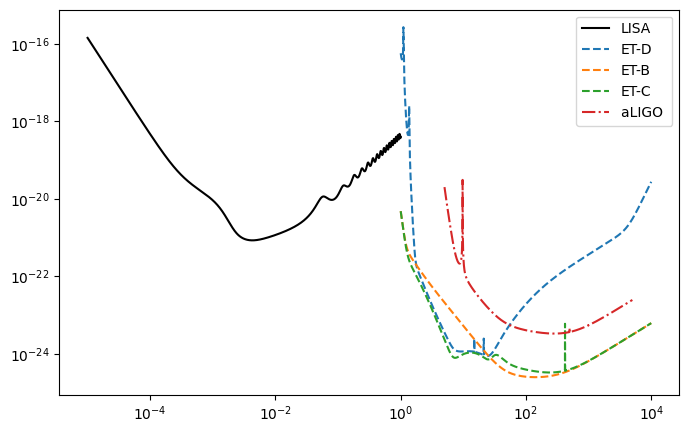

In [68]:
fig, ax = plt.subplots(figsize=(8, 5))
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k')
# ET sensitivity curves for 3 configurations
et_sensitivities = {
    'ET-D': np.loadtxt('ET_D_sensi.txt'),
    'ET-B': np.loadtxt('ET_B_sensi.txt'),
    'ET-C': np.loadtxt('ET_C_sensi.txt')
}
for label, data in et_sensitivities.items():
    ax.loglog(data[:, 0], data[:, 1], label=label, linestyle='--')
# aLIGO sensitivity curve
aligo_sensitivity = np.loadtxt('aLIGO_sensi.txt')
ax.loglog(aligo_sensitivity[:, 0], aligo_sensitivity[:, 1], label='aLIGO ', linestyle='-.')
ax.legend(loc='upper right')

plt.show()

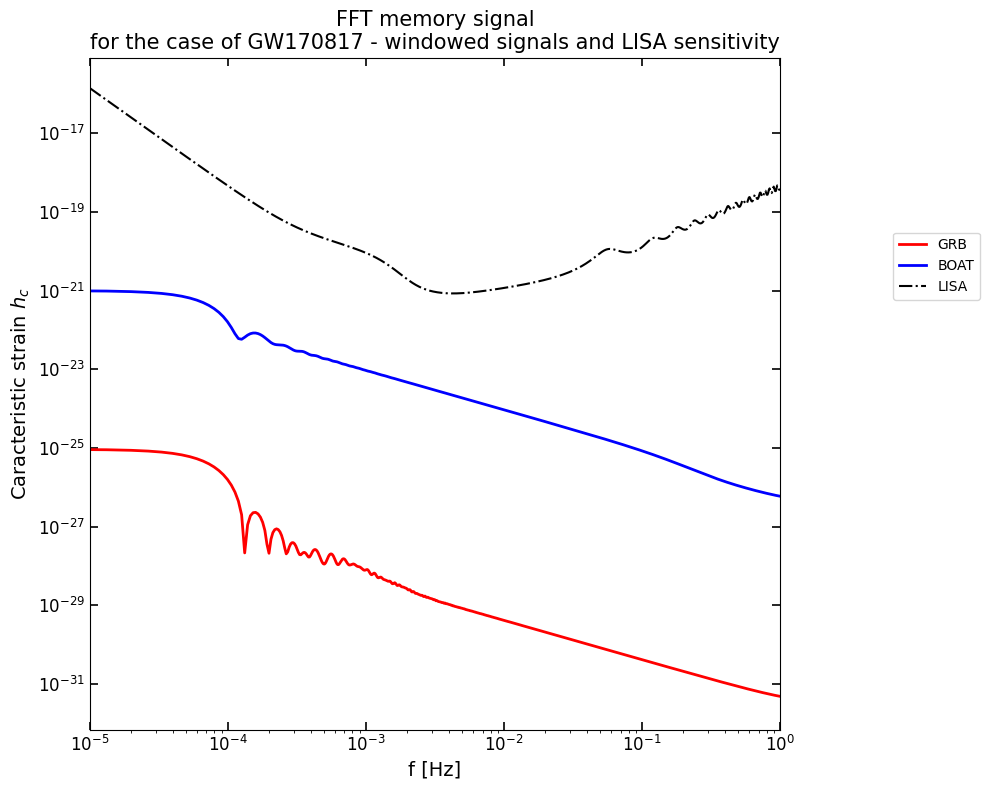

In [69]:
t = np.linspace(-1., 150., 500000) * 1e3  # ms

E_j = 1e51  # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
theta = np.deg2rad(30)  
beta = 0.99  
tau_grb_ms = 100  # ms
start_grb, end_grb = 0, 30e3 #end at 30s 

h_grb = up.phenom_memory_GRB(t, E_j, beta, theta, r, tau_grb_ms, start_grb, end_grb, model='exponential', plot=False)

h_list = [h_grb, h_boat]
labels = ['GRB', 'BOAT']


# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g', 'violet']
for idx, h in enumerate(h_list): # exclude the sensitivity curve from the windowing of course
    # we apply a Tukey window to the padded signal to further reduce edge effects
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)

# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and LISA sensitivity',
    return_fig=True
)
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.75), ncol= 1)
ax.set_xlim(1e-5, 1)
plt.show()

Try to reproduce plots of https://arxiv.org/pdf/gr-qc/0405067

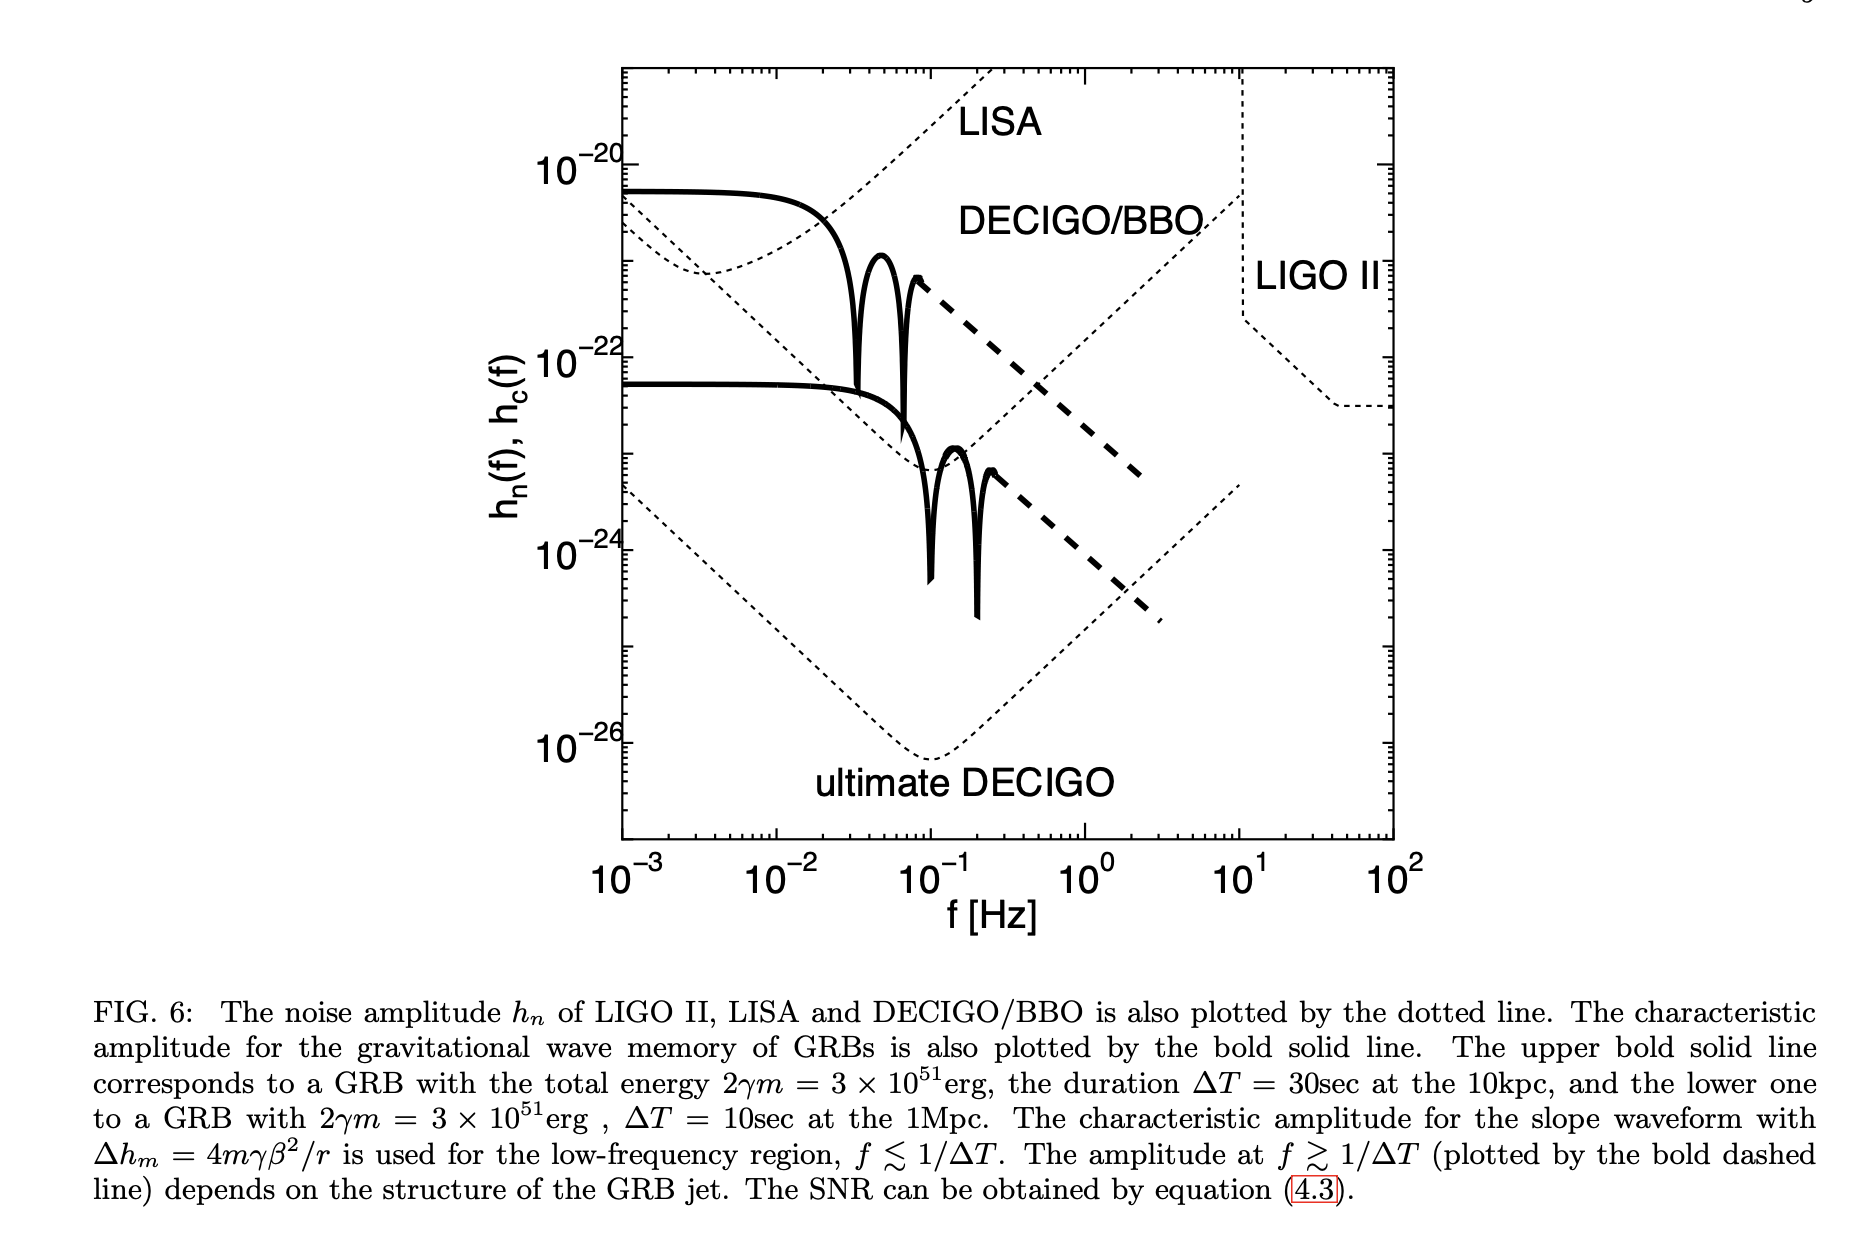

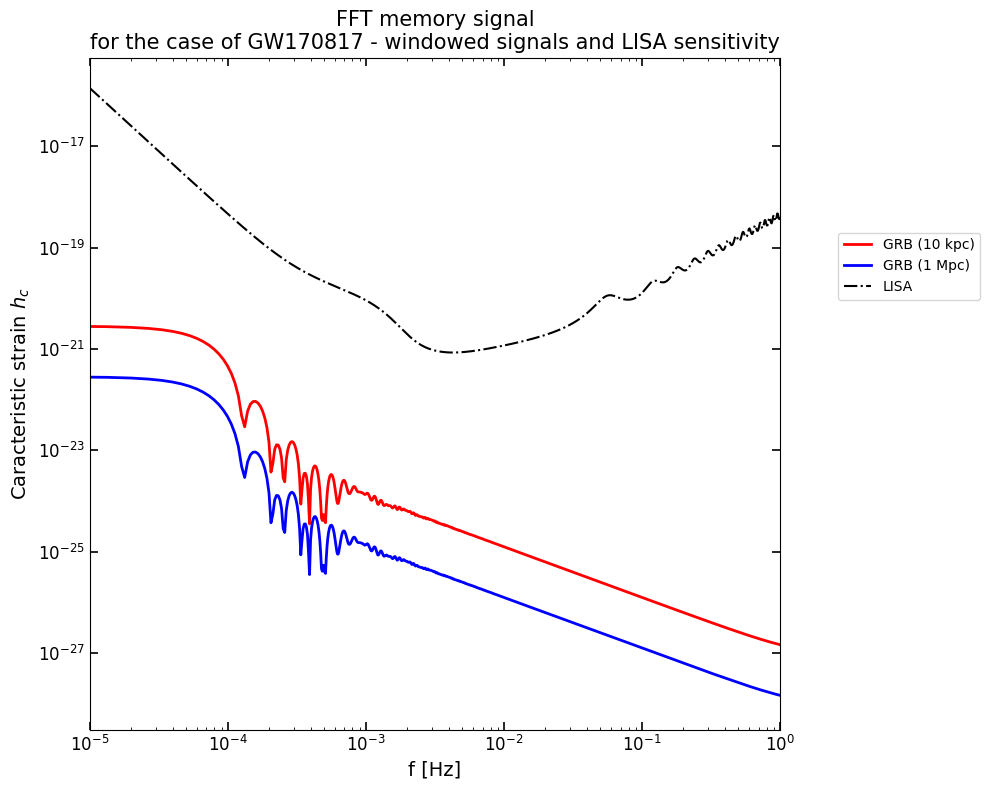

In [70]:
t = np.linspace(-1., 150., 500000) * 1e3  # ms
theta = np.deg2rad(30)
h_grb_1 = up.phenom_memory_GRB(t, 3e51, beta, theta, 10e3, 1e3, start_grb, 30e3, model='exponential', plot=False) # 10 kpc case
h_grb_2 = up.phenom_memory_GRB(t, 3e52, beta, theta, 1e6, 1e3, start_grb, 10e3, model='exponential', plot=False) # 1 Mpc case

h_list = [h_grb_1, h_grb_2]
labels = ['GRB (10 kpc)', 'GRB (1 Mpc)']
# Tulkey window
h_windowed=[]
colors = ['r', 'b', 'g']
for idx, h in enumerate(h_list): 
    h_w =using.apply_window(h, window_type='tukey', alpha=0.1)
    h_windowed.append(h_w)
    
# Summary fft plot
fig, ax = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=True, show=False,
    add_info_title='for the case of GW170817 - windowed signals and LISA sensitivity',
    return_fig=True
)
# LISA
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')

ax.tick_params(axis='both', labelsize=12, which='both', direction='in', top=True, right=True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.75), ncol= 1)
ax.set_xlim(1e-5, 1)
plt.show()

## Test of a new formula for the FFT of the memory signal based on formula (4.2) provided by https://arxiv.org/pdf/gr-qc/0405067

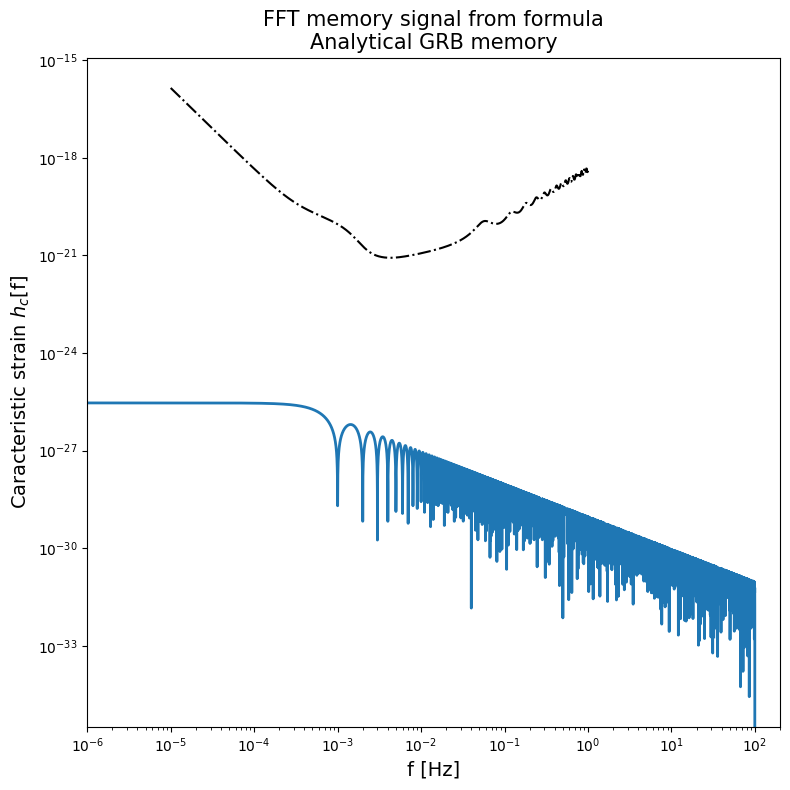

In [71]:
E_j = 1e50   
beta = 0.99
theta = np.deg2rad(30)
r = 100 * 1e6 # 100 Mpc
delta_h_grb = up.delta_h_GRB(E_j, beta, theta, r)
tau_grb = 1e3  # ms
_,_=up.memory_fft_formula(
    delta_h_grb, tau_grb, plot=True, show=True, add_info_title='Analytical GRB memory', LISA= True)


Now we can compare with my method for the 2 cases mentioned above

<Figure size 800x800 with 0 Axes>

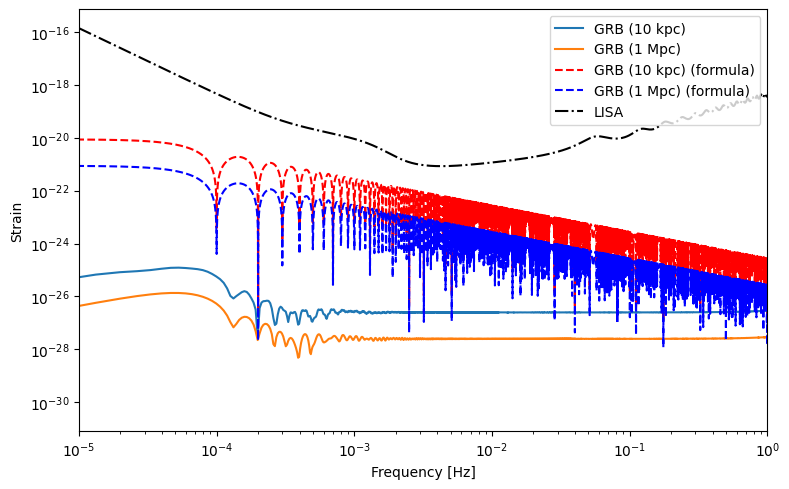

In [86]:
t = np.linspace(-1., 150., 500000) * 1e3  # ms
theta = np.deg2rad(30)
E_1, E_2 = 3e51, 3e52
beta = 0.99
tau_grb_ms = 10e3
r_1, r_2 = 10e3, 1e6
start_grb = 0
end_1, end_2 = 30e3, 10e3
h_list =[]
# Compute the memory amplitude for both cases
delta_h_1 = up.delta_h_GRB(E_1, beta, theta, r_1)
delta_h_2 = up.delta_h_GRB(E_2, beta, theta, r_2)

# Compute GRB memory signals for two cases
h_grb_1 = up.phenom_memory_GRB(t, E_1, beta, theta, r_1, end_1, start_grb, end_1, model='exponential', plot=False)
h_grb_2 = up.phenom_memory_GRB(t, E_2, beta, theta, r_2, end_2, start_grb, end_2, model='exponential', plot=False)

# Apply Tukey window
h_windowed = [
    using.apply_window(h_grb_1, window_type='tukey', alpha=0.1),
    using.apply_window(h_grb_2, window_type='tukey', alpha=0.1)
]
labels = ['GRB (10 kpc)', 'GRB (1 Mpc)']
colors = ['r', 'b']

# Compute FFT for windowed signals
results = up.memory_fft_phenom(
    t, h_windowed, labels=labels, plot=False, show=False, return_fft=True
)

# Analytical FFTs
freq_1, fft_1 = up.memory_fft_formula(delta_h_1, tau_grb_ms, plot=False, show=False)
freq_2, fft_2 = up.memory_fft_formula(delta_h_2, tau_grb_ms, plot=False, show=False)

# Final plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, (freq, fft) in enumerate(results):
    plt.plot(freq, fft, label=labels[i])
ax.loglog(freq_1, np.abs(fft_1), label=f'{labels[0]} (formula)', color=colors[0], linestyle='--')
ax.loglog(freq_2, np.abs(fft_2), label=f'{labels[1]} (formula)', color=colors[1], linestyle='--')
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')
ax.legend(loc='upper right')
ax.set_xlim(1e-5, 1)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Strain')
plt.tight_layout()
plt.show()

### Analytical fft only for the GRB memory

[30, 10, 10, 1, 10, 0.001, 10]


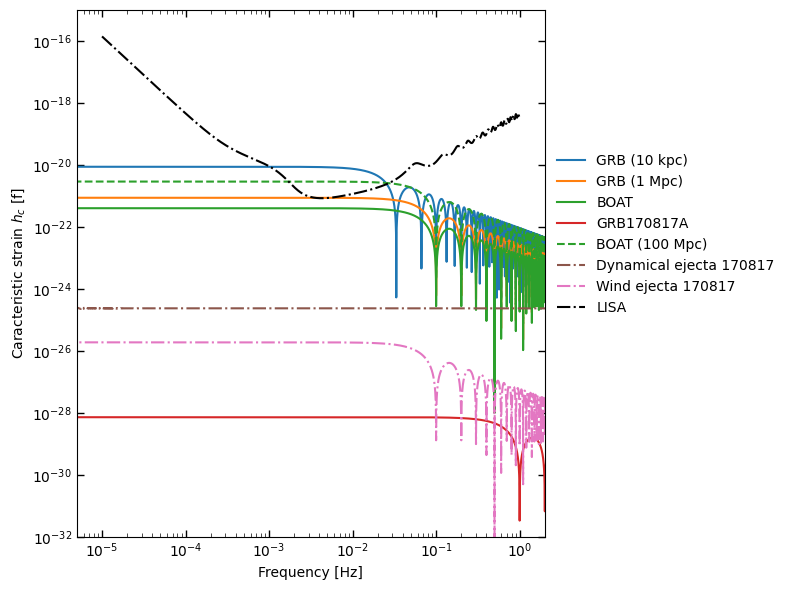

In [148]:
delta_h_BOAT = up.delta_h_GRB(E_j_boat, beta_boat, theta_boat, r_boat)
delta_h_BOAT_100MPC = up.delta_h_GRB(E_j_boat, beta_boat, theta_boat, 100*1e6)
delta_h_170817 = up.delta_h_GRB(E_j_170817, beta_170817, theta_170817, r_170817)
delta_h_170817_dyn = up.delta_h_ejecta(M_ej_dyn, v_ej_dyn, r_170817)
delta_h_170817_wind = up.delta_h_ejecta(M_ej_wind, v_ej_wind, r_170817)
delta_h_all = [delta_h_1, delta_h_2, delta_h_BOAT, delta_h_170817, delta_h_BOAT_100MPC , delta_h_170817_dyn, delta_h_170817_wind]

labels = ['GRB (10 kpc)', 'GRB (1 Mpc)', 'BOAT', 'GRB170817A', 'BOAT (100 Mpc)', 'Dynamical ejecta 170817', 'Wind ejecta 170817']
tau_grbs = [30, 10, 10, 1, 10,  1e-3, 10]
cmap = plt.get_cmap('tab20')
colors = [cmap(i) for i in range(0, 14, 2)] 
colors[4] = colors[2] # same color for BOAT at 100 Mpc and GRB at 1 Mpc
ls_list = ['-', '-', '-', '-', '--', '-.', '-.']
print(tau_grbs)
freq_fft_list = []
for delta_h, tau_grb in zip(delta_h_all, tau_grbs):
    f_test, fft = up.memory_fft_formula(delta_h, tau_grb, plot=False, show=False, LISA=False)
    freq_fft_list.append((f_test, np.abs(fft)))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

for i, (f_test, fft) in enumerate(freq_fft_list):
    ax.loglog(f_test, fft, label=labels[i], color=colors[i], linestyle=ls_list[i])
ax.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 0.75), frameon= False)

ax.tick_params(axis='both', which='major', direction='in', length=5, width=1, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5, top=True, right=True)


ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'Caracteristic strain $h_c$ [f]')
ax.set_xlim(5e-6, 2e0)
ax.set_ylim(1e-32, 1e-15)
plt.tight_layout()
plt.savefig(out_dir + "fft_memory_phenom_all_cases_with_LISA_analytical_f.png")
plt.show()

Figure to depict the impact of the factors on the memory signal and its FFT

In [ ]:
t = np.linspace(-1., 150., 500000) 
beta = 1
theta = np.deg2rad(30) # viewing angle of 30 degrees with respect to the jet axis
duration = 10 # s
E_typical = 1e50 # erg
r_typical = 1e6 # 1 Mpc
tau_grb = 1e-3 # short timescale as mentionned by Lopez (so a caracteristic frequency of 1 kHz ~ LIGO band)

h_typical = up.phenom_memory_GRB(t, E_typical, beta, theta, r_typical, 1e3, 0, 30e3, model='exponential', plot=False)

In [35]:
print(f'{1/(2e3):.1e}')

5.0e-04


Afterglow parameters: 1e+49 200.0 0.17453292519943295 1000000.0 0.99 1e+51 2000.0
delta_h_min_aft 2.4052619307957897e-25 delta_h_max_aft 2.40526193079579e-22


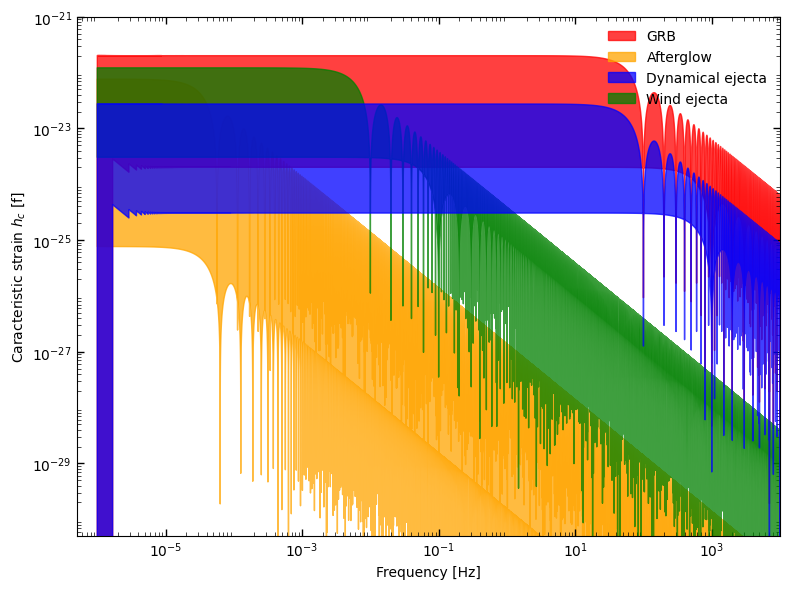

In [41]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

r = 1 * 1e6  # 1 Mpc
beta = 0.99
theta_v_jet = 2 * np.deg2rad(5) # Twice opnenig angle 
theta_opening_jet = np.deg2rad(5)

# Paramètres min/max pour chaque composant
E_jet_min, E_jet_max = 1e50, 1e52
tau_GRB_min, tau_GRB_max = 1e-3, 10e-3

P_aft_min, P_aft_max = 1e49, 1e51
tau_aft_min, tau_aft_max = 2e2, 2e3 # SGRB - LGRB afterglow timescales

M_dyn_min, M_dyn_max = 0.1e-2, 1e-2
v_dyn_min, v_dyn_max = 0.1, 0.3
tau_dyn_min, tau_dyn_max = 1e-3, 10e-3

M_wind_min, M_wind_max = 0.01, 0.1
v_wind_min, v_wind_max = 0.1, 0.2
tau_wind_min, tau_wind_max = 1e1, 1e2


# FFT pour chaque composant
# GRB 
delta_h_min = up.delta_h_GRB(E_jet_min, beta, theta_v_jet, r)
delta_h_max = up.delta_h_GRB(E_jet_max, beta, theta_v_jet, r)
fft_min = up.memory_fft_formula(delta_h_min, tau_GRB_min, plot=False, show=False, LISA=False)
fft_max = up.memory_fft_formula(delta_h_max, tau_GRB_max, plot=False, show=False, LISA=False)

# Afterglow 
print("Afterglow parameters:", P_aft_min, tau_aft_min, theta_v_jet, r, beta, P_aft_max, tau_aft_max)
delta_h_min_aft = up.memory_afterglow_injection(P_aft_min, tau_aft_min, theta_v_jet, theta_opening_jet, r, beta)
delta_h_max_aft = up.memory_afterglow_injection(P_aft_max, tau_aft_max, theta_v_jet, theta_opening_jet, r, beta)
print("delta_h_min_aft", delta_h_min_aft, "delta_h_max_aft", delta_h_max_aft)
fft_min_aft = up.new_fft(0, delta_h_min_aft, tau_aft_min, theta_v_jet)
fft_max_aft = up.new_fft(0, delta_h_max_aft, tau_aft_max, theta_v_jet)
# Dynamical ejecta
delta_h_min_dyn = up.delta_h_ejecta(M_dyn_min, v_dyn_min, r)
delta_h_max_dyn = up.delta_h_ejecta(M_dyn_max, v_dyn_max, r)
fft_min_dyn = up.memory_fft_formula(delta_h_min_dyn, tau_dyn_min, plot=False, show=False, LISA=False)
fft_max_dyn = up.memory_fft_formula(delta_h_max_dyn, tau_dyn_max, plot=False, show=False, LISA=False)

# Wind ejecta
delta_h_min_wind = up.delta_h_ejecta(M_wind_min, v_wind_min, r)
delta_h_max_wind = up.delta_h_ejecta(M_wind_max, v_wind_max, r)
fft_min_wind = up.memory_fft_formula(delta_h_min_wind, tau_wind_min, plot=False, show=False, LISA=False)
fft_max_wind = up.memory_fft_formula(delta_h_max_wind, tau_wind_max, plot=False, show=False, LISA=False)

# Sort by max(fft_max) to have the most important component on top in the plot
components = [
    {"GRB":  fft_max},
    {"Afterglow": fft_max_aft},
    {"Dynamical ejecta": fft_max_dyn},
    {"Wind ejecta": fft_max_wind}
]
# Sort the components by the maximum value of their fft_max to ensure the most important component is plotted on top
components.sort(key=lambda x: list(x.values())[0][1].max(), reverse=True)
zorder_dict = {list(comp.keys())[0]: idx for idx, comp in enumerate(components)}

fig, ax = plt.subplots(figsize=(8, 6))

ax.fill_between(fft_min[0], fft_min[1], fft_max[1], color='red', alpha=0.75, label='GRB', zorder=zorder_dict['GRB'])
ax.fill_between(fft_min_aft[0], 2*fft_min_aft[0] * fft_min_aft[1], 2*fft_min_aft[0] * fft_max_aft[1], color='orange', alpha=0.75, label='Afterglow', zorder=zorder_dict['Afterglow'])
ax.fill_between(fft_min_dyn[0], fft_min_dyn[1], fft_max_dyn[1], color='blue', alpha=0.75, label='Dynamical ejecta', zorder=zorder_dict['Dynamical ejecta'])
ax.fill_between(fft_min_wind[0], fft_min_wind[1], fft_max_wind[1], color='green', alpha=0.75, label='Wind ejecta', zorder=zorder_dict['Wind ejecta'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'Caracteristic strain $h_c$ [f]')
ax.legend(loc='upper right', frameon=False)

# Minor ticks for log axes
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

ax.tick_params(axis='both', which='major', direction='in', length=5, width=1, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5, top=True, right=True)

ax.set_xlim(5e-7, 1e4)
ax.set_ylim(5e-31, 1e-21)
plt.tight_layout()
plt.show()


In [42]:
def rectangular_fft(fft_max, tau, f):
    fft = np.zeros_like(f)
    mask_low = f < 1/tau
    mask_high = f >= 1/tau
    fft[mask_low] = fft_max
   
    fft[mask_high] = fft_max * (1/tau) / f[mask_high]
    return fft

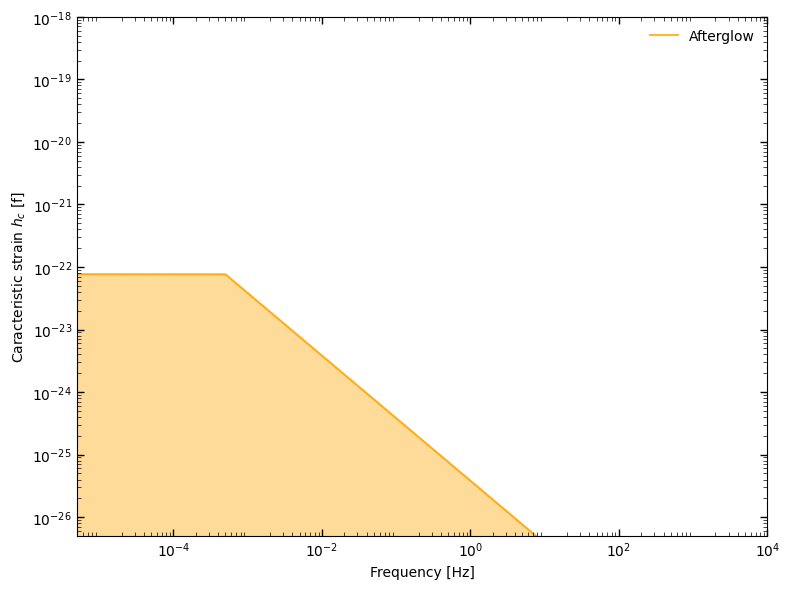

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))
# ax.plot(fft_max[0], rectangular_fft(max(fft_max[1]), tau_GRB_max, fft_max[0]), color='red', alpha=0.8, label='GRB', zorder = zorder_dict['GRB'])
# ax.fill_between(fft_max[0], 0, rectangular_fft(max(fft_max[1]), tau_GRB_max, fft_max[0]), color='red', alpha=0.4, zorder = zorder_dict['GRB'])

ax.plot(fft_min_aft[0], rectangular_fft(max( 2*fft_min_aft[0] * fft_max_aft[1]), tau_aft_max, fft_min_aft[0]), color='orange', alpha=0.8, label='Afterglow', zorder = zorder_dict['Afterglow'])
ax.fill_between(fft_min_aft[0], 0, rectangular_fft(max( 2*fft_min_aft[0] * fft_max_aft[1]), tau_aft_max, fft_min_aft[0]), color='orange', alpha=0.4, zorder = zorder_dict['Afterglow'])

# ax.plot(fft_min_dyn[0], rectangular_fft(max(fft_max_dyn[1]), tau_dyn_max, fft_min_dyn[0]), color='blue', alpha=0.8, label='Dynamical ejecta', zorder = zorder_dict['Dynamical ejecta'])
# ax.fill_between(fft_min_dyn[0], 0, rectangular_fft(max(fft_max_dyn[1]), tau_dyn_max, fft_min_dyn[0]), color='blue', alpha=0.4, zorder = zorder_dict['Dynamical ejecta'])

# ax.plot(fft_min_wind[0], rectangular_fft(max(fft_max_wind[1]), tau_wind_max, fft_min_wind[0]), color='green', alpha=0.8, label='Wind ejecta', zorder = zorder_dict['Wind ejecta'])
# ax.fill_between(fft_min_wind[0], 0, rectangular_fft(max(fft_max_wind[1]), tau_wind_max, fft_min_wind[0]), color='green', alpha=0.4, zorder = zorder_dict['Wind ejecta'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'Caracteristic strain $h_c$ [f]')
ax.legend(loc='upper right', frameon=False)

# Minor ticks for log axes
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=100))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

ax.tick_params(axis='both', which='major', direction='in', length=5, width=1, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5, top=True, right=True)

ax.set_xlim(5e-6, 1e4)
ax.set_ylim(5e-27, 1e-18)
plt.tight_layout()
plt.show()

To find the f_min, we have to know the total duration of the asssociated event. Thus the memory signal is not present for f < 1/T, where T is the total duration of the event. 

---

## Test of GRB + afterglow memory from https://arxiv.org/pdf/2301.12590

Initial memory amplitude from the GRB: 2.90e-23
Inverse of the rise time of the afterglow memory: 5.00e-03 Hz
Memory amplitude from the afterglow injection: 1.10e-26
Inverse of the rise time of the afterglow memory: 5.00e-03 Hz
Memory amplitude from the afterglow injection: 1.10e-25
Inverse of the rise time of the afterglow memory: 5.00e-03 Hz
Memory amplitude from the afterglow injection: 1.10e-24


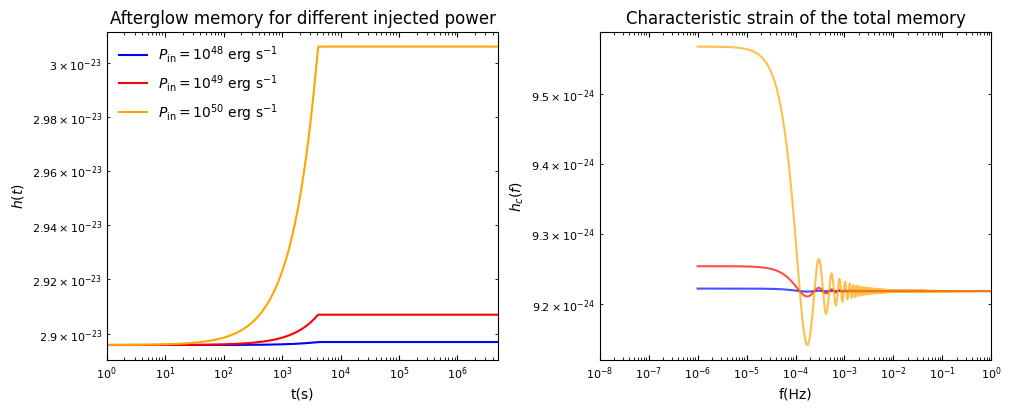

In [26]:
importlib.reload(up)
cases = [
    (r'$P_\mathrm{in} = 10^{48}$ erg s$^{-1}$', 1e48, 'blue'),
    (r'$P_\mathrm{in} = 10^{49}$ erg s$^{-1}$', 1e49, 'red'),
    (r'$P_\mathrm{in} = 10^{50}$ erg s$^{-1}$', 1e50, 'orange'),
]
# GRB memory 
E_j = 1e51 # <-- problem with the GRB amplitude : too high compare to other methods
theta_j = np.deg2rad(5) # jet opening angle
theta_v = np.deg2rad(2.5) # Viewing angle 
theta_ej = 2*theta_v
phi_ej = 0
beta = 0.99
r = 1 * 1e6 # 1 Mpc

h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)
print(f"Initial memory amplitude from the GRB: {h_in:.2e}")
t = np.linspace(-1, 5e6, int(5e6)) # -1 s to 1e6 s
t_end = 2e2 # 200 s for SGRB
# Afterglow memory
fig, (ax_1, ax_2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for label, P_in, color in cases:
    # Waveform
    h_afterglow = up.memory_afterglow_injection(P_in, t_end, theta_ej, theta_j, r,  beta)
    print(f"Inverse of the rise time of the afterglow memory: {1/t_end:.2e} Hz")
    print(f"Memory amplitude from the afterglow injection: {h_afterglow:.2e}")
    h_t, t_m = up.memory_total_waveform(t, h_in, h_afterglow, t_end, theta_ej)
    ax_1.loglog(t, h_t, label=label, color=color)

    # FFT
    f, fft = up.new_fft(h_in, h_afterglow, t_end, theta_ej)
    ax_2.loglog(f, 2*f*np.abs(fft), label=label, color=color, alpha = 0.7) # Plot of the characteristic strain

ax_1.set_xlabel('t(s)')
#ax_1.hlines(h_in, t[0], t[-1], label='Initial memory', color='k', linestyle='--')
#ax_1.vlines(t_m, h_in, h_t[-1], color='grey', linestyle= 'dotted', alpha=0.7, label=f'{t_m:.2e}  end time') 
ax_1.set_ylabel(r'$h(t)$')
ax_1.set_title('Afterglow memory for different injected power')

ax_1.set_xlim(1e0, t[-1])
ax_1.legend(loc = 'upper left', frameon= False)
ax_1.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)

ax_2.set_xlabel('f(Hz)')
ax_2.set_ylabel(r'$h_c(f)$')
ax_2.set_title('Characteristic strain of the total memory')
ax_2.set_xlim(1e-8, 1e0)

ax_2.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)

plt.show()


In [75]:
# GRB memory 
E_j = 1e51
theta_j = np.deg2rad(5) # jet opening angle
theta_v = np.deg2rad(5) # Viewing angle 
theta_ej = 2*theta_v
phi_ej = 0
beta = 0.99
r = 1 * 1e6 # 1 Mpc

h_in = up.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)

# Afterglow memory
P_in = 1e50
t_end = 2e2 # 200 s for SGRB
h_afterglow = up.memory_afterglow_injection(P_in, t_end, theta_ej, theta_j, r,  beta)

print(f"Initial memory amplitude: {h_in:.2e}, Afterglow memory amplitude: {h_afterglow:.2e}, Ratio: {h_in/h_afterglow:.2f}")

Initial memory amplitude: 6.32e-23, Afterglow memory amplitude: 2.41e-24, Ratio: 26.28


Test BOAT & GW170817

Properties for BOAT: {'E_j': 1e+55, 'theta_j': 0.08726646259971647, 'theta_v': 0.08726646259971647, 'theta_ej': 0.17453292519943295, 'phi_ej': 0, 'beta': 0.99, 'r': 724000000.0, 'tau_grb_s': 10, 'end_grb_s': 600, 'P_in': 1e+50}
Properties for GRB170817A: {'E_j': 1e+47, 'theta_j': 0.08726646259971647, 'theta_v': 0.08726646259971647, 'theta_ej': 0.17453292519943295, 'phi_ej': 0, 'beta': 0.99, 'r': 40000000.0, 'tau_grb_170817_s': 1, 'end_grb_170817_s': 2000, 'P_in': 1e+50}


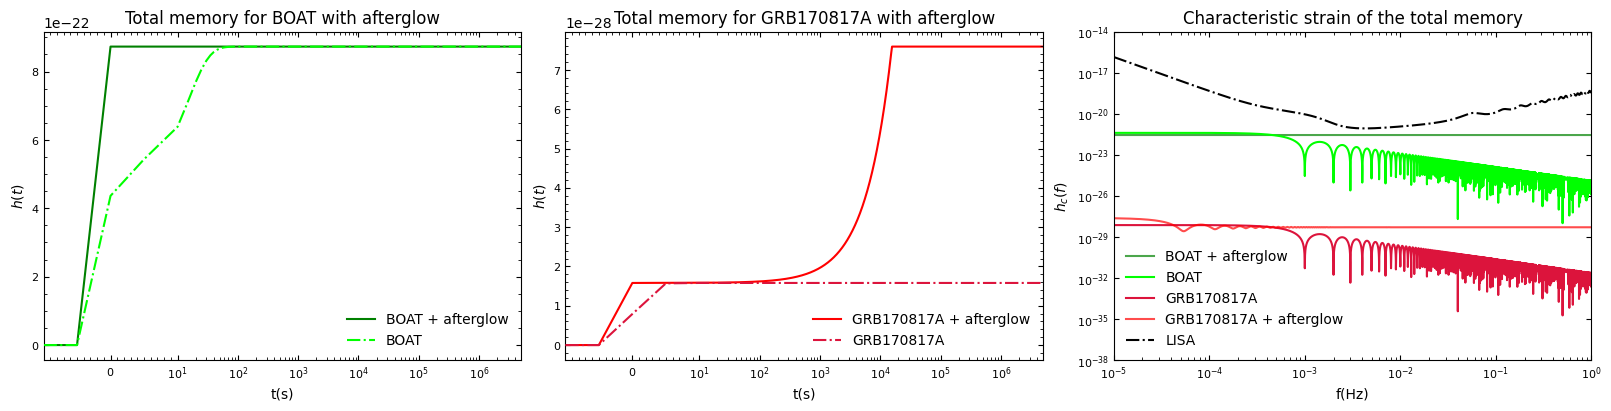

In [76]:
from matplotlib.ticker import  SymmetricalLogLocator
t = np.linspace(-10, 5e6, int(1e6)) # -1 s to 5e6 s
# BOAT case
prop_BOAT = {
    'E_j': 1e55,   # brightest object
    'theta_j': np.deg2rad(5), # jet opening angle
    'theta_v': np.deg2rad(5), # Viewing angle
    'theta_ej': 2*np.deg2rad(5),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 724 * 1e6, # BOAT
    'tau_grb_s': 10, # ms duration of the GRB
    'end_grb_s': 600, # end GRB at 600s
    'P_in': 1e50, # injected power for the afterglow
}
print(f"Properties for BOAT: {prop_BOAT}")
E_j_boat = prop_BOAT['E_j']
theta_j = prop_BOAT['theta_j']
theta_v = prop_BOAT['theta_v']
theta_ej = prop_BOAT['theta_ej']
phi_ej = prop_BOAT['phi_ej']
beta = prop_BOAT['beta']
r_boat = prop_BOAT['r']
tau_grb_boat_s = prop_BOAT['tau_grb_s'] 
end_grb_boat = prop_BOAT['end_grb_s']
P_in = prop_BOAT['P_in']

h_t_BOAT_old = up.phenom_memory_GRB(
    t, E_j_boat, beta, theta_ej, r_boat, tau_grb_boat_s, 0, end_grb_boat, model='exponential', plot=False)

h_in_BOAT = up.memory_initial_acceleration_GRB(E_j_boat, theta_ej, phi_ej, r_boat, beta)
t_end_BOAT = 600# 600s for BOAT
h_afterglow_BOAT = up.memory_afterglow_injection(P_in, t_end_BOAT, theta_ej, theta_j, r_boat,  beta)
h_tot_BOAT, _ = up.memory_total_waveform(t, h_in_BOAT, h_afterglow_BOAT, t_end_BOAT, theta_ej)

f_BOAT, fft_BOAT = up.new_fft(h_in_BOAT, h_afterglow, t_end_BOAT, theta_ej)

# 170817 case
prop_170817 = {
    'E_j': 1e47,   # low luminosity of GRB170817A (https://arxiv.org/pdf/2006.02060)
    'theta_j': np.deg2rad(5), # jet opening angle
    'theta_v': np.deg2rad(5), # Viewing angle 
    'theta_ej': 2*np.deg2rad(5),
    'phi_ej': 0,
    'beta': 0.99,
    'r': 40 * 1e6, # 40 Mpc
    'tau_grb_170817_s': 1, # ms duration of the GRB
    'end_grb_170817_s': 2000, # end GRB at 2000s
    'P_in': 1e50, # injected power for the afterglow
}
print(f"Properties for GRB170817A: {prop_170817}")
E_j_170817 = prop_170817['E_j']
theta_j = prop_170817['theta_j']
theta_v = prop_170817['theta_v']
theta_ej = prop_170817['theta_ej']
phi_ej = prop_170817['phi_ej']
beta = prop_170817['beta']
r_170817 = prop_170817['r']
tau_grb_170817_s = prop_170817['tau_grb_170817_s']
end_grb_170817 = prop_170817['end_grb_170817_s']
P_in = prop_170817['P_in']

h_t_170817_old = up.phenom_memory_GRB(
    t, E_j_170817, beta, theta_ej, r_170817, tau_grb_170817_s, 0, end_grb_170817, model='exponential', plot=False)

h_in_170817 = up.memory_initial_acceleration_GRB(E_j_170817, theta_ej, phi_ej, r_170817, beta)
t_end_170817 = 2 # 2s for 170817
h_afterglow_170817 = up.memory_afterglow_injection(P_in, t_end_170817, theta_ej, theta_j, r_170817, beta)
h_tot_170817, _ = up.memory_total_waveform(t, h_in_170817, h_afterglow_170817, t_end_170817, theta_ej)

f_170817, fft_170817 = up.new_fft(h_in_170817, h_afterglow_170817, t_end_170817, theta_ej)

fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
ax1.plot(t, h_tot_BOAT, label='BOAT + afterglow', color='green', zorder = 1)
ax1.plot(t, h_t_BOAT_old, label='BOAT', color='lime', ls='-.', zorder = 10)
ax2.plot(t, h_tot_170817, label='GRB170817A + afterglow', color='red', zorder = 1)
ax2.plot(t, h_t_170817_old, label='GRB170817A', color='crimson', ls='-.', zorder = 10)
for ax in [ax1, ax2]:
    ax.set_xlabel('t(s)', fontsize=10)
    ax.set_xscale('symlog', linthresh=10, linscale=1.0)
    ax.set_ylabel(r'$h(t)$', fontsize=10)
    ax.set_title('Total memory for ' + ('BOAT' if ax == ax1 else 'GRB170817A') + ' with afterglow')
    ax.set_xlim(-10, t[-1])
    ax.legend(loc = 'lower right', frameon= False)
    ax.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True) 
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(
        SymmetricalLogLocator(linthresh=1, base=10, subs=[x for x in range(1, 10)]))
    

ax3.loglog(f_BOAT, 2 * f_BOAT * np.abs(fft_BOAT), label='BOAT + afterglow', color='green', alpha = 0.7)
colors = ['lime', 'crimson']
for i, (f_test, fft) in enumerate(freq_fft_list):
    if i == 2 or i == 3: # only plot the analytical FFT for BOAT and 170817
        ax3.loglog(f_test, fft, label=labels[i], color=colors[i-2])
ax3.loglog(f_170817,2 * f_170817 * np.abs(fft_170817), label='GRB170817A + afterglow', color='red', alpha = 0.7)
#LISA sensitivity curve
import LISA as li
lisa = li.LISA() # initialize LISA object

f  = np.logspace(np.log10(1.0e-5), np.log10(1.0e0), 1000)
Sn = lisa.Sn(f)

ax3.loglog(f, np.sqrt(f*Sn), label='LISA', color='k', linestyle='-.')
ax3.set_xlabel('f(Hz)', fontsize=10)
ax3.set_ylabel(r'$h_c(f)$', fontsize=10)
ax3.set_title('Characteristic strain of the total memory')
ax3.set_ylim(1e-38, 1e-14)
ax3.set_xlim(1e-5, 1e0)

ax3.tick_params(axis='both', labelsize=8, which='both', direction='in', top=True, right=True)
ax3.legend(loc = 'lower left', frameon= False)
plt.savefig(out_dir + "total_memory_afterglow_BOAT_170817.png")
plt.show()
